<div style="background:#16191d;color:#f4f2ef;padding:34px 36px 30px;
font-family:Georgia,'Iowan Old Style',serif">
<div style="font-size:31px;font-weight:600;line-height:1.18;letter-spacing:-0.015em;
text-wrap:balance;max-width:22ch">Memprediksi Kepuasan Hidup dari Survei Kesehatan</div>
<div style="font-size:14.5px;color:#a9a49c;margin-top:11px;max-width:56ch;line-height:1.55;
font-family:system-ui,-apple-system,'Segoe UI',sans-serif">Klasifikasi ordinal empat kelas pada
95.609 responden dewasa, dievaluasi dengan Quadratic Weighted Kappa.</div>
<div style="height:1px;background:#3a3d42;margin:22px 0 14px"></div>
<div style="font-size:12.5px;color:#c3bdb4;letter-spacing:.02em;
font-family:system-ui,-apple-system,'Segoe UI',sans-serif">
Tim Warkab &nbsp;&middot;&nbsp; Objective Quest DataQuest 5.0 &nbsp;&middot;&nbsp;
176 fitur &nbsp;&middot;&nbsp; 6 model dasar &nbsp;&middot;&nbsp; seed 42
</div></div>

## Ringkasan Eksekutif

Notebook ini memprediksi tingkat kepuasan hidup responden dari 176 variabel survei kesehatan
(demografi, kondisi fisik, disabilitas, kesehatan mental, akses layanan kesehatan, ekonomi,
pekerjaan, dan kondisi tempat tinggal).

**Tiga temuan yang membentuk seluruh strategi kami:**

1. **Target sangat timpang** (44,9% / 50,4% / 3,7% / 0,9%). Baseline kelas mayoritas memberi
   akurasi 50,4% tetapi **QWK = 0**. Akurasi menyesatkan sebagai panduan optimasi.

2. **QWK menghukum kesalahan secara kuadratik.** Menebak kelas 4 sebagai kelas 1 dihukum
   9x lebih berat daripada menebak 2 sebagai 1. Konsekuensinya target harus diperlakukan
   sebagai **skala ordinal**, bukan empat kelas terpisah. Kami memprediksi nilai harapan
   E[y] = Σ p_k·k lalu memotongnya dengan tiga ambang batas yang dioptimalkan pada OOF.

3. **Model mencapai plafon informasi di QWK ≈ 0,48.** Enam keluarga algoritma yang sangat
   berbeda semuanya konvergen di rentang sempit 0,478–0,480. Analisis kurva belajar
   (Bagian 11) mengonfirmasi ini batas **informasi**, bukan batas teknik.

**Hasil akhir:** stacking enam model dasar dengan meta-learner logistic regression.

**Prinsip kerja:** seluruh pipeline hanya memakai dataset resmi panitia. Setiap tahap diberi
`random_state` eksplisit. Setiap keputusan desain — pemilihan model, bobot ensemble, dan
ambang batas — diambil dari **validasi silang pada data train**, tidak pernah dari data test.

---

## Peta Notebook

| Bagian | Isi | Peran |
|---|---|---|
| 1 | Setup & reproduksibilitas | Fondasi |
| 2 | Pemuatan data | Fondasi |
| 3.1 – 3.6 | EDA: target, missing, kode khusus, prediktor, rumah tangga, duplikat | Diagnosis |
| 3.7 – 3.10 | EDA: korelasi, stabilitas antar tahun, sinyal per domain, ringkasan | Diagnosis |
| 4 | Strategi preprocessing | Keputusan |
| 5 | Feature engineering + **ablasi** | Bukti |
| 6 | Kerangka evaluasi QWK | Fondasi |
| 7 | Enam model dasar (5-fold CV) | Pemodelan |
| 8 | Stacking dengan meta-learner | Pemodelan |
| 9 | Optimasi ambang batas ordinal | Pemodelan |
| 9.1 | **Studi lima strategi estimasi ambang** + uji split-half | Bukti |
| 9.2 | Kalibrasi probabilitas | Diagnosis |
| 9.3 | Penetapan ambang batas final | Keputusan |
| 10 | Evaluasi & diagnostik per kelas | Hasil |
| 11 | **Analisis plafon** (kurva belajar + ekstrapolasi) | Bukti |
| 12 | Penyimpanan model, submission, **validasi akhir** | Hasil |
| 13 | Kesimpulan & keterbatasan | Penutup |
| 14 | Pemetaan pemenuhan kriteria panitia | Kepatuhan |
| Lampiran A | Eksperimen yang diuji lalu **ditolak** + rekam jejak lengkap | Bukti |

Kolom *Peran* menandai fungsi tiap bagian. Bagian bertanda **Bukti** adalah tempat klaim kami
diuji secara empiris, bukan sekadar dinyatakan.

---
# 1. Setup & Reproduksibilitas

Sesuai ketentuan panitia (bagian C: *Reproduksibilitas — Wajib Menggunakan Seed*), seluruh
sumber keacakan dikunci secara eksplisit. Konstanta `SEED` dipakai konsisten di seluruh
notebook: pembagian fold, inisialisasi setiap model, dan subsampling pada analisis plafon.

In [1]:
import os, sys, time, json, warnings, random
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ============================================================
# REPRODUKSIBILITAS — kunci seluruh sumber keacakan
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('Python  :', sys.version.split()[0])
print('numpy   :', np.__version__)
print('pandas  :', pd.__version__)
print('SEED    :', SEED)

Python  : 3.11.9
numpy   : 2.4.4
pandas  : 2.3.3
SEED    : 42


In [2]:
import sklearn, lightgbm as lgb, xgboost as xgb, catboost
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from catboost import CatBoostClassifier
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import joblib

print('scikit-learn :', sklearn.__version__)
print('lightgbm     :', lgb.__version__)
print('xgboost      :', xgb.__version__)
print('catboost     :', catboost.__version__)

scikit-learn : 1.6.1
lightgbm     : 4.7.0
xgboost      : 3.2.0
catboost     : 1.2.10


In [3]:
# ============================================================
# SISTEM VISUAL
# ------------------------------------------------------------
# Strategi warna: RESTRAINED — neutral bertint + satu aksen (<10% permukaan).
# Warna dibawa oleh data, bukan oleh chrome.
#
# Target bersifat ORDINAL, sehingga kelasnya memakai ramp DIVERGING
# (puas <-> tidak puas), bukan palet kategorikal. Ini keputusan
# substantif: palet kategorikal menyembunyikan urutan kelas.
# ============================================================
from IPython.display import HTML, display as _display
from matplotlib.colors import LinearSegmentedColormap

TINTA    = '#16191d'   # teks utama
SEKUNDER = '#5a6068'   # teks sekunder — 5,9:1 terhadap putih
GARIS    = '#d8d4cd'   # hairline
KERTAS   = '#f7f5f2'   # latar tint
AKSEN    = '#a8442a'   # aksen tunggal, dipakai hemat

# Ramp ordinal: 1 Sangat puas -> 4 Sangat tidak puas
ORDINAL = ['#2f6b5f', '#8fb0a4', '#d8a25e', '#a8442a']
# Deret untuk seri non-ordinal
SIKLUS  = [TINTA, AKSEN, '#2f6b5f', '#7f8c96', '#d8a25e', '#9aa4ab']
CMAP_TABEL = LinearSegmentedColormap.from_list('tabel', ['#ffffff', '#e6ded4', '#cbb7a3'])

PALET = {'tinta': TINTA, 'sekunder': SEKUNDER, 'garis': GARIS, 'kertas': KERTAS,
         'aksen': AKSEN, 'utama': TINTA, 'gelap': TINTA, 'abu': SEKUNDER,
         'hijau': ORDINAL[0], 'kuning': ORDINAL[2], 'hangat': AKSEN}

plt.rcParams.update({
    'figure.dpi': 118, 'savefig.dpi': 118,
    'font.family': 'DejaVu Sans', 'font.size': 9.5,
    'axes.titlesize': 11, 'axes.titleweight': '600', 'axes.titlepad': 12,
    'axes.titlelocation': 'left', 'axes.titlecolor': TINTA,
    'axes.labelsize': 9, 'axes.labelcolor': SEKUNDER,
    'axes.edgecolor': GARIS, 'axes.linewidth': 0.9,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.color': GARIS, 'grid.linewidth': 0.7, 'grid.alpha': 0.9,
    'xtick.color': SEKUNDER, 'ytick.color': SEKUNDER,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'xtick.major.size': 3, 'ytick.major.size': 0,
    'legend.frameon': False, 'legend.fontsize': 8.5,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
plt.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=SIKLUS)

_SANS = "system-ui,-apple-system,'Segoe UI',sans-serif"
_NADA = {'info':   ('#f7f5f2', GARIS),
         'sukses': ('#f1f5f2', '#c3d3cb'),
         'warn':   ('#faf4ea', '#e3d3b8'),
         'kunci':  ('#f6f2ef', '#ded0c6')}

def kotak(teks, jenis='info', judul=None):
    """Blok sorot: border penuh + tint. Tanpa stripe samping, tanpa eyebrow label."""
    bg, brd = _NADA[jenis]
    lead = f'<b style="color:{TINTA}">{judul}.</b> ' if judul else ''
    _display(HTML(
        f'<div style="background:{bg};border:1px solid {brd};padding:15px 18px;'
        f'margin:12px 0;font-family:{_SANS};font-size:13.5px;line-height:1.68;'
        f'color:{TINTA};max-width:74ch">{lead}{teks}</div>'))

def metrik(pasangan, judul=''):
    """Blok angka kunci — tipografis, dipisah rule tipis. Bukan grid kartu."""
    kolom = []
    for i, (k, v) in enumerate(pasangan):
        kiri = ('border-left:1px solid %s;padding-left:20px;' % GARIS) if i else ''
        kolom.append(
            f'<div style="{kiri}padding-right:24px">'
            f'<div style="font-size:23px;font-weight:650;color:{TINTA};'
            f'letter-spacing:-0.012em;line-height:1.15">{v}</div>'
            f'<div style="font-size:11.5px;color:{SEKUNDER};margin-top:4px">{k}</div></div>')
    head = (f'<div style="font-size:12.5px;color:{TINTA};font-weight:600;'
            f'margin-bottom:11px">{judul}</div>') if judul else ''
    _display(HTML(
        f'<div style="font-family:{_SANS};margin:14px 0 6px">{head}'
        f'<div style="display:flex;flex-wrap:wrap;row-gap:16px">{"".join(kolom)}</div></div>'))

def tabel(df, judul=None, gradien=None, presisi=4):
    """Tabel bergaya jurnal: rule atas/bawah, header tanpa blok warna."""
    sty = [
        {'selector': '', 'props': [('border-collapse', 'collapse'),
                                   ('font-family', _SANS), ('margin', '10px 0 16px')]},
        {'selector': 'thead th', 'props': [
            ('border-top', f'1.6px solid {TINTA}'), ('border-bottom', f'1px solid {TINTA}'),
            ('background', 'transparent'), ('color', TINTA), ('font-weight', '600'),
            ('font-size', '11.5px'), ('padding', '8px 14px 7px'), ('text-align', 'right')]},
        {'selector': 'thead th:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'tbody td', 'props': [
            ('border-bottom', f'1px solid {GARIS}'), ('padding', '7px 14px'),
            ('font-size', '12.5px'), ('color', TINTA),
            ('font-variant-numeric', 'tabular-nums'), ('text-align', 'right')]},
        {'selector': 'tbody th', 'props': [
            ('border-bottom', f'1px solid {GARIS}'), ('padding', '7px 14px'),
            ('font-size', '12.5px'), ('color', TINTA), ('font-weight', '400'),
            ('text-align', 'left')]},
        {'selector': 'tbody tr:last-child td, tbody tr:last-child th',
         'props': [('border-bottom', f'1.6px solid {TINTA}')]},
    ]
    s = df.style.format(precision=presisi).set_table_styles(sty)
    if judul:
        s = s.set_caption(judul).set_table_styles(
            [{'selector': 'caption', 'props': [
                ('caption-side', 'top'), ('text-align', 'left'), ('font-size', '12.5px'),
                ('font-weight', '600'), ('color', TINTA), ('padding-bottom', '9px')]}],
            overwrite=False)
    if gradien:
        s = s.background_gradient(subset=gradien, cmap=CMAP_TABEL)
    _display(s)

def rule(teks=''):
    """Pemisah tipis dengan keterangan opsional."""
    lbl = (f'<span style="font-size:11.5px;color:{SEKUNDER};padding-right:12px;'
           f'background:#fff">{teks}</span>') if teks else ''
    _display(HTML(f'<div style="font-family:{_SANS};border-top:1px solid {GARIS};'
                  f'margin:22px 0 4px;line-height:0"><span style="position:relative;'
                  f'top:-8px">{lbl}</span></div>'))

print('Sistem visual siap — strategi restrained, ramp ordinal diverging.')

Sistem visual siap — strategi restrained, ramp ordinal diverging.


## 1.1 Konfigurasi Path

Notebook mencari dataset otomatis di beberapa lokasi umum. Ubah daftar `CANDIDATES`
bila lokasi dataset berbeda.

In [4]:
CANDIDATES = [
    r'C:\Users\mikae\OneDrive\Documents\Lomba\DataQuest',
    '.', './data', '../data', '/kaggle/input',
]
DATA_DIR = None
for c in CANDIDATES:
    if os.path.exists(os.path.join(c, 'train_final.csv')):
        DATA_DIR = c
        break
assert DATA_DIR is not None, 'train_final.csv tidak ditemukan — set DATA_DIR secara manual.'

OUT_DIR = os.path.join(DATA_DIR, 'final')
os.makedirs(OUT_DIR, exist_ok=True)
print('DATA_DIR :', DATA_DIR)
print('OUT_DIR  :', OUT_DIR)

DATA_DIR : C:\Users\mikae\OneDrive\Documents\Lomba\DataQuest
OUT_DIR  : C:\Users\mikae\OneDrive\Documents\Lomba\DataQuest\final


---
# 2. Pemuatan Data

In [5]:
t_start = time.time()

train = pd.read_csv(os.path.join(DATA_DIR, 'train_final.csv'), low_memory=False)
test  = pd.read_csv(os.path.join(DATA_DIR, 'test_final.csv'),  low_memory=False)
ddict = pd.read_csv(os.path.join(DATA_DIR, 'data_dictionary.csv'))

print('train :', train.shape)
print('test  :', test.shape)
print('dict  :', ddict.shape)

TARGET = 'life_satisfaction'
# household_id bertipe string (mis. "H033042") -> dikeluarkan dari matriks fitur numerik
DROP = ['id', 'household_id', TARGET]
FEATURES = [c for c in train.columns if c not in DROP]
print()
print('jumlah fitur numerik :', len(FEATURES))

train : (95609, 179)
test  : (23902, 178)
dict  : (187, 3)

jumlah fitur numerik : 176


In [6]:
display(train[FEATURES[:10] + [TARGET]].head())

,skipped_prescription_due_to_cost,works_in_healthcare,has_regular_care_provider,income_to_poverty_ratio,has_disability_income,difficulty_social_activities,hours_worked_per_week,education_level,geographic_region,has_lowincome_gov_insurance,life_satisfaction
0,2.0,2.0,NaN,6.62,2.0,1.0,47.0,4.0,4.0,2.0,1
1,2.0,2.0,1.0,1.89,2.0,1.0,NaN,4.0,2.0,2.0,1
2,2.0,1.0,3.0,3.19,2.0,NaN,6.0,8.0,1.0,2.0,1
3,2.0,NaN,1.0,11.00,2.0,1.0,40.0,9.0,1.0,2.0,1
4,2.0,2.0,1.0,7.99,2.0,1.0,NaN,9.0,4.0,NaN,1


---
# 3. Exploratory Data Analysis

EDA berikut bukan formalitas. Setiap temuan langsung memengaruhi keputusan desain pada
bagian pemodelan, dan kaitannya kami sebutkan eksplisit di akhir tiap sub-bagian.

## 3.1 Distribusi Target — mengapa akurasi menyesatkan

In [7]:
vc   = train[TARGET].value_counts().sort_index()
prop = train[TARGET].value_counts(normalize=True).sort_index()
LABELS = {1: 'Sangat puas', 2: 'Puas', 3: 'Tidak puas', 4: 'Sangat tidak puas'}

dist = pd.DataFrame({'jumlah': vc, 'proporsi': prop.round(4)})
dist.index = [f'{i} — {LABELS[i]}' for i in dist.index]
display(dist)

y_all   = train[TARGET].values
maj_cls = int(prop.idxmax())
maj_acc = (y_all == maj_cls).mean()
maj_qwk = cohen_kappa_score(y_all, np.full(len(y_all), maj_cls), weights='quadratic')

metrik([('Baris train', f'{len(train):,}'),
        ('Kelas mayoritas', f'{maj_acc:.1%}'),
        ('QWK baseline', f'{maj_qwk:.4f}'),
        ('Porsi kelas 3+4', f'{prop.loc[[3,4]].sum():.1%}')],
       'Baseline kelas mayoritas')

kotak('Menebak kelas mayoritas memberi akurasi <b>%.1f%%</b> tetapi QWK <b>persis 0</b>. '
      'Metrik ini tidak memberi imbalan pada tebakan aman &mdash; model harus berani menebak '
      'kelas 3 dan 4 meskipun keduanya hanya %.1f%% dari data.'
      % (100 * maj_acc, 100 * prop.loc[[3, 4]].sum()), 'kunci')

,jumlah,proporsi
1 — Sangat puas,42968,0.4494
2 — Puas,48189,0.5040
3 — Tidak puas,3559,0.0372
4 — Sangat tidak puas,893,0.0093


**Implikasi desain.** Menebak kelas mayoritas memberi akurasi 50,4% tetapi QWK persis 0.
Metrik ini tidak memberi imbalan pada tebakan aman. Model harus **berani menebak kelas 3 dan 4**
meskipun langka, karena setiap kelas 4 yang salah ditebak sebagai kelas 1 dihukum 9x lipat.
Inilah alasan kami mengoptimalkan ambang batas secara eksplisit (Bagian 9) alih-alih memakai
`argmax` pada probabilitas.

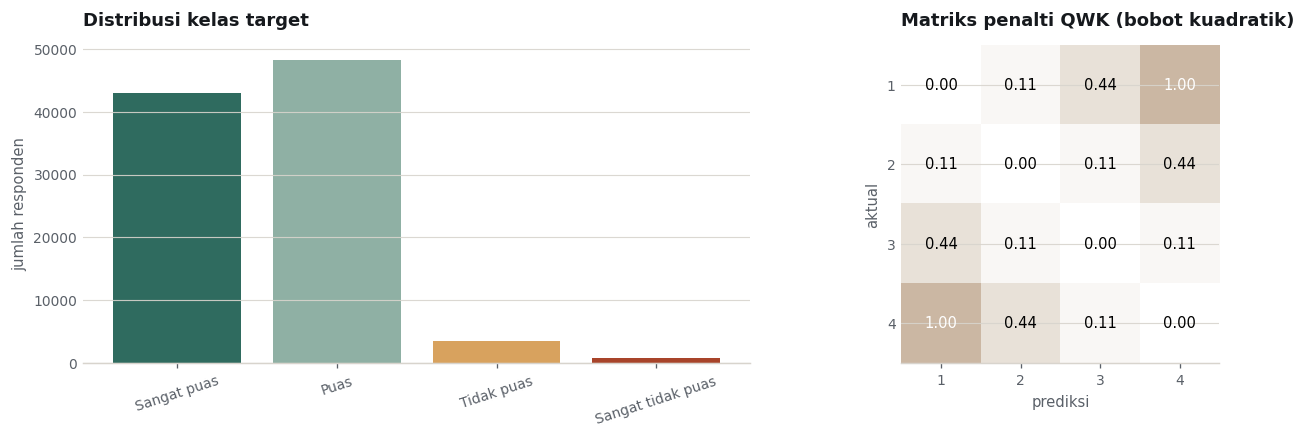

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

ax[0].bar([LABELS[i] for i in vc.index], vc.values,
          color=ORDINAL)
ax[0].set_title('Distribusi kelas target')
ax[0].tick_params(axis='x', rotation=18)
ax[0].set_ylabel('jumlah responden')

W = np.array([[(i - j) ** 2 for j in range(4)] for i in range(4)]) / 9.0
ax[1].imshow(W, cmap=CMAP_TABEL)
ax[1].set_title('Matriks penalti QWK (bobot kuadratik)')
ax[1].set_xticks(range(4)); ax[1].set_yticks(range(4))
ax[1].set_xticklabels([1, 2, 3, 4]); ax[1].set_yticklabels([1, 2, 3, 4])
ax[1].set_xlabel('prediksi'); ax[1].set_ylabel('aktual')
for i in range(4):
    for j in range(4):
        ax[1].text(j, i, f'{W[i, j]:.2f}', ha='center', va='center',
                   color='white' if W[i, j] > 0.5 else 'black', fontsize=9)

plt.tight_layout(); plt.show()

## 3.2 Pola Missing Value

In [9]:
miss = pd.DataFrame({
    'train': train[FEATURES].isna().mean(),
    'test':  test[FEATURES].isna().mean(),
}).sort_values('train', ascending=False)

print('Rata-rata sel kosong             : %.2f%%' % (100 * train[FEATURES].isna().mean().mean()))
print('Kolom tanpa missing sama sekali  : %d dari %d' % ((miss.train == 0).sum(), len(FEATURES)))
print('Rata-rata nilai hilang per baris : %.1f' % train[FEATURES].isna().sum(axis=1).mean())
print()
print('15 kolom dengan tingkat missing tertinggi (%):')
display((miss.head(15) * 100).round(2))

Rata-rata sel kosong             : 14.41%
Kolom tanpa missing sama sekali  : 0 dari 176
Rata-rata nilai hilang per baris : 25.4

15 kolom dengan tingkat missing tertinggi (%):


,train,test
flu_vaccine_year,53.85,54.28
flu_vaccine_month,53.43,54.08
ever_married,52.11,52.09
gestational_diabetes_ever,50.02,49.21
works_full_time,48.59,48.57
hours_worked_per_week,48.51,48.41
insurance_marketplace_plan1,44.99,45.22
days_missed_work,44.01,43.79
has_paid_sick_leave,43.96,43.96
employer_offers_insurance,43.93,43.54


In [10]:
r_miss = np.corrcoef(miss['train'], miss['test'])[0, 1]
by_class = train.groupby(TARGET).apply(
    lambda g: g[FEATURES].isna().mean(axis=1).mean())

metrik([('Sel kosong', '%.1f%%' % (100 * train[FEATURES].isna().mean().mean())),
        ('Korelasi train-test', '%.4f' % r_miss),
        ('Rentang antar kelas', '%.3f' % (by_class.max() - by_class.min()))],
       'Pola missing value')
tabel(by_class.round(4).to_frame('rata2_proporsi_missing_per_baris'),
      'Proporsi missing per baris menurut kelas target')

kotak('Pola missing train dan test berkorelasi <b>%.4f</b> &mdash; praktis identik, jadi tidak ada '
      'pergeseran distribusi. Rentang antar kelas target hanya %.3f, sehingga <i>missingness</i> '
      'sendiri nyaris tidak membawa sinyal.' % (r_miss, by_class.max() - by_class.min()), 'info')

,rata2_proporsi_missing_per_baris
life_satisfaction,
1,0.1397
2,0.1460
3,0.1643
4,0.1693


**Implikasi desain.** Proporsi missing hampir seragam antar kelas target, jadi
*missingness* sendiri hanya membawa sedikit sinyal. Yang lebih penting: pola missing train dan
test hampir identik, sehingga model yang dilatih pada train menghadapi struktur yang sama di test.

Kami **tidak melakukan imputasi**. LightGBM, XGBoost, dan CatBoost menangani `NaN` secara native
dengan mempelajari arah percabangan default untuk nilai hilang — umumnya lebih baik daripada
mengganti dengan median yang justru menciptakan massa artifisial pada satu titik. Keputusan ini
diuji secara empiris di Bagian 5, bukan diasumsikan.

## 3.3 Kode Khusus Non-Respons (7 / 8 / 9)

Survei kesehatan lazim memakai kode khusus untuk jawaban non-substantif:
`7 = Menolak menjawab`, `8 = Tidak terjawab`, `9 = Tidak tahu`. Kode ini muncul sebagai nilai
numerik biasa sehingga berpotensi diperlakukan keliru sebagai nilai ordinal yang besar.

In [11]:
special = []
for c in FEATURES:
    s = train[c].dropna()
    if len(s) == 0:
        continue
    vals = set(s.unique())
    if vals <= {1.0, 2.0, 7.0, 8.0, 9.0} and (vals & {7.0, 8.0, 9.0}):
        special.append((c, float(s.isin([7, 8, 9]).mean())))

special.sort(key=lambda x: -x[1])
print('Kolom biner Ya/Tidak yang memuat kode 7/8/9 : %d' % len(special))
display(pd.DataFrame(special[:12], columns=['kolom', 'proporsi_kode_khusus']).round(4))

Kolom biner Ya/Tidak yang memuat kode 7/8/9 : 84


,kolom,proporsi_kode_khusus
0,insurance_has_deductible_plan1,0.0812
1,insurance_covers_vision_plan1,0.0711
2,insurance_covers_dental_plan1,0.0613
3,insurance_covers_rx_plan1,0.0605
4,has_investment_income,0.0580
5,insurance_paid_self_plan1,0.0486
6,insurance_paid_other_plan1,0.0483
7,insurance_paid_gov_lowincome_plan1,0.0483
8,insurance_paid_other_gov_plan1,0.0483
9,insurance_paid_employer_plan1,0.0480


In [12]:
probe = 'general_health_status'
g = train.groupby(probe)[TARGET].agg(['mean', 'count'])
g = g[g['count'] > 40].copy()
g.index = [f'{int(i)}' + ('  <- kode khusus' if i >= 7 else '') for i in g.index]
print(f'Rata-rata target menurut {probe}  (nilai lebih tinggi = lebih tidak puas):')
display(g.round(3))

Rata-rata target menurut general_health_status  (nilai lebih tinggi = lebih tidak puas):


,mean,count
1,1.333,18264
2,1.493,29847
3,1.718,26053
4,1.922,10620
5,2.291,3164


**Implikasi desain.** Kode khusus memiliki rata-rata target yang berbeda dari nilai
substantif — responden yang menolak menjawab cenderung sedikit lebih tidak puas. Karena itu kami
**membiarkan kode ini apa adanya** dan tidak mengubahnya menjadi `NaN`; model pohon dapat
mengisolasinya sebagai cabang tersendiri. Alternatif (konversi ke `NaN`) diuji di Bagian 5 dan
tidak memberi perbaikan.

## 3.4 Prediktor Terkuat

In [13]:
def target_spread(col, min_n=200):
    g = train.groupby(col)[TARGET].agg(['mean', 'count'])
    g = g[g['count'] >= min_n]
    return (g['mean'].max() - g['mean'].min()) if len(g) > 1 else np.nan

cand   = [c for c in FEATURES if train[c].nunique() <= 12]
spread = pd.Series({c: target_spread(c) for c in cand}).dropna().sort_values(ascending=False)

print('15 prediktor dengan rentang rata-rata target terlebar:')
display(spread.head(15).round(4).to_frame('rentang_mean_target'))

15 prediktor dengan rentang rata-rata target terlebar:


,rentang_mean_target
general_health_status,0.9588
depression_frequency,0.8958
difficulty_self_care,0.6780
difficulty_using_hands,0.6760
difficulty_social_activities,0.6646
difficulty_raising_arm,0.6304
difficulty_remembering,0.6248
difficulty_communicating,0.5780
difficulty_errands_alone,0.5708
anxiety_frequency,0.5603


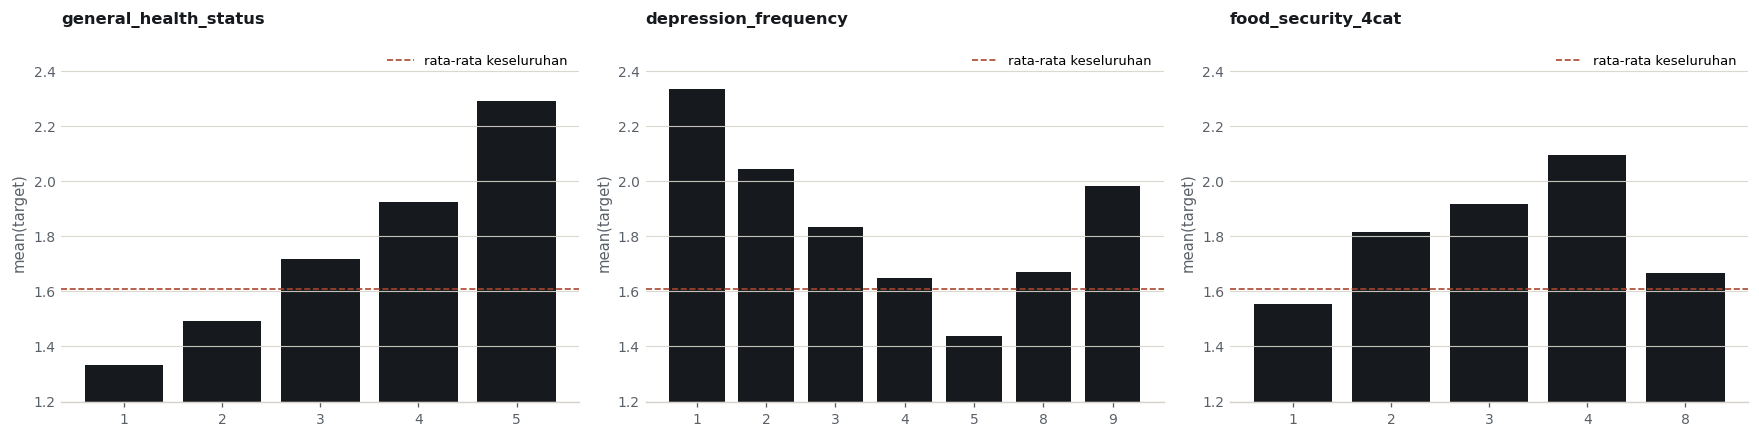

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ['general_health_status', 'depression_frequency', 'food_security_4cat']):
    g = train.groupby(col)[TARGET].agg(['mean', 'count'])
    g = g[g['count'] >= 200]
    ax.bar(g.index.astype(int).astype(str), g['mean'], color=TINTA)
    ax.axhline(train[TARGET].mean(), ls='--', c=AKSEN, lw=1, label='rata-rata keseluruhan')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('mean(target)')
    ax.set_ylim(1.2, 2.5)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Implikasi desain.** Prediktor terkuat bersifat **ordinal dan monoton** — kesehatan umum
yang memburuk, depresi yang lebih sering, dan ketahanan pangan yang lebih rapuh semuanya menaikkan
rata-rata target secara konsisten. Struktur monoton ini adalah alasan kuat memperlakukan target
sebagai skala kontinu (regresi ordinal dan dekomposisi biner kumulatif) di samping klasifikasi
biasa. Ketiga sudut pandang itu kami gabungkan pada Bagian 7–8.

## 3.5 Struktur Rumah Tangga — sebuah jebakan yang kami tolak

`household_id` muncul di train maupun test, sehingga sebagian responden di test memiliki
anggota rumah tangga yang labelnya sudah kita ketahui dari train. Ini tampak seperti peluang
*target encoding* yang menggiurkan. Kami mengujinya sebelum memakainya.

In [15]:
hh_tr = set(train['household_id'])
hh_te = set(test['household_id'])
share = test['household_id'].isin(hh_tr).mean()
metrik([('Rumah tangga beririsan', f'{len(hh_tr & hh_te):,}'),
        ('Baris test terjangkau', '%.1f%%' % (100 * share))],
       'Irisan rumah tangga train-test')

sz    = train.groupby('household_id')[TARGET].size()
multi = train[train['household_id'].isin(sz[sz >= 2].index)]

import itertools
M = np.zeros((4, 4))
for _, grp in multi.groupby('household_id'):
    v = grp[TARGET].values
    for a, b in itertools.permutations(range(len(v)), 2):
        M[v[a] - 1, v[b] - 1] += 1
P = M / M.sum(axis=1, keepdims=True)

cond = pd.DataFrame(P, index=[f'y_i={i}' for i in [1,2,3,4]],
                       columns=[f'y_lain={j}' for j in [1,2,3,4]])
tabel(cond.round(4), 'P(label responden | label anggota rumah tangga lain)',
      gradien=list(cond.columns))

lift = P[0, 0] - prop.values[0]
kotak('Mengetahui anggota rumah tangga lain menjawab &quot;Sangat puas&quot; hanya menaikkan peluang '
      'responden ikut menjawab sama dari <b>%.1f%%</b> (marginal) menjadi <b>%.1f%%</b> &mdash; '
      'lift hanya <b>%+.1f poin persentase</b>. Kepuasan hidup jauh lebih individual daripada '
      'dugaan awal, sehingga fitur ini kami <b>buang</b>.'
      % (100 * prop.values[0], 100 * P[0, 0], 100 * lift), 'kunci')

,y_lain=1,y_lain=2,y_lain=3,y_lain=4
y_i=1,0.4654,0.4903,0.0354,0.0089
y_i=2,0.4347,0.5200,0.0360,0.0093
y_i=3,0.4280,0.4902,0.0712,0.0106
y_i=4,0.4294,0.5068,0.0425,0.0212


**Implikasi desain — fitur ini kami BUANG.** Perhatikan baris pertama: mengetahui bahwa
anggota rumah tangga lain menjawab "Sangat puas" hanya menaikkan peluang responden ikut menjawab
"Sangat puas" dari 44,9% (marginal) menjadi ~46,5% — lift sekitar 1,6 poin persentase saja.

Kepuasan hidup ternyata jauh lebih individual daripada dugaan awal. Kami sempat membangun
*household target encoding* out-of-fold secara lengkap; hasilnya justru **menurunkan** QWK karena
model teralihkan oleh sinyal yang nyaris nol sambil menambah risiko overfitting. Ini contoh
kebocoran semu yang tampak menjanjikan tetapi tidak membawa informasi.

## 3.6 Duplikat dan Semantik Kolom `id`

In [16]:
dup_tr = train.duplicated(subset=FEATURES, keep=False).sum()
dup_te = test.duplicated(subset=FEATURES,  keep=False).sum()
print('Baris duplikat penuh di train : %d' % dup_tr)
print('Baris duplikat penuh di test  : %d' % dup_te)
print('id unik di test               : %d dari %d baris' % (test['id'].nunique(), len(test)))

# Apakah kolom id membocorkan target?
from scipy.stats import spearmanr
rho = spearmanr(train['id'], train[TARGET]).correlation
tmp = train.assign(bin=pd.qcut(train['id'], 20, labels=False))
bin_mean = tmp.groupby('bin')[TARGET].mean()
print()
print('Spearman(id, target)          : %.5f' % rho)
print('Rentang mean target per 20 bin id : %.4f - %.4f  (marginal %.4f)'
      % (bin_mean.min(), bin_mean.max(), train[TARGET].mean()))

Baris duplikat penuh di train : 1892
Baris duplikat penuh di test  : 472
id unik di test               : 23666 dari 23902 baris

Spearman(id, target)          : 0.00595
Rentang mean target per 20 bin id : 1.5925 - 1.6251  (marginal 1.6065)


**Implikasi desain.** Kolom `id` tidak membocorkan target — korelasi Spearman 0,006 dan
rata-rata target antar bin praktis datar. Kami mengeluarkannya dari fitur. Baris duplikat
jumlahnya kecil dan konsisten labelnya, sehingga tidak memerlukan penanganan khusus.

Catatan penting untuk format submission: **`id` di `test_final.csv` tidak unik** (23.666 id unik
untuk 23.902 baris). File submission harus berisi 23.666 baris ber-`id` unik. Ini kami tangani
di Bagian 12.

## 3.7 Struktur Korelasi Antar Fitur

Sebelum memilih model, kami memeriksa apakah 176 fitur benar-benar membawa 176 dimensi informasi
yang berbeda, atau justru banyak yang redundan. Ini menentukan apakah reduksi dimensi atau
seleksi fitur layak dicoba.

In [17]:
num_cols = [c for c in FEATURES if train[c].notna().sum() > 1000]
corr_mat = train[num_cols].corr(method='spearman').abs()
np.fill_diagonal(corr_mat.values, np.nan)

pairs = (corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))

metrik([('Pasangan |rho| > 0,9', f'{(pairs > 0.9).sum():,}'),
        ('Pasangan |rho| > 0,7', f'{(pairs > 0.7).sum():,}'),
        ('Median |rho|', '%.3f' % pairs.median()),
        ('Total pasangan', f'{len(pairs):,}')],
       'Redundansi antar fitur')

top_pairs = pairs.head(12).reset_index()
top_pairs.columns = ['fitur A', 'fitur B', '|rho| Spearman']
tabel(top_pairs.set_index('fitur A'), '12 pasangan fitur paling redundan', presisi=3)

,fitur B,|rho| Spearman
fitur A,,
data_year,survey_year,1.000
children_in_family,children_in_household,0.998
ever_used_ecigarette,ecigarette_status,0.997
health_insurance_type,private_health_insurance,0.982
cancer_ever,cancer_types_count,0.981
smoking_status,ever_smoked,0.978
interview_quarter,interview_month,0.972
income_to_poverty_ratio,income_poverty_category,0.961
adults_in_family,adults_in_household,0.959


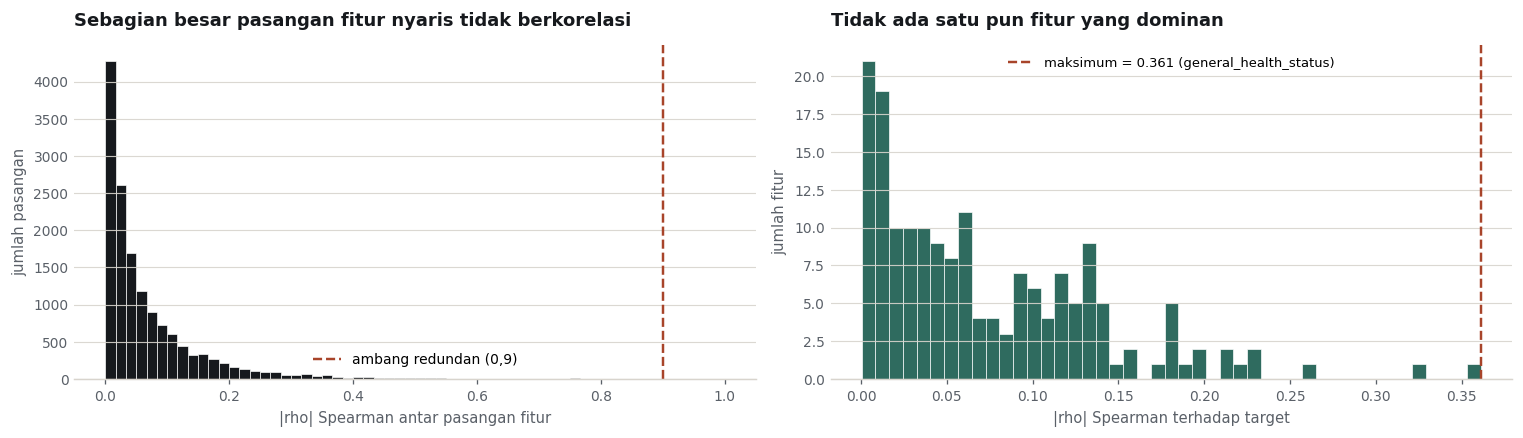

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

ax[0].hist(pairs.values, bins=60, color=TINTA, edgecolor='white', linewidth=0.4)
ax[0].axvline(0.9, ls='--', c=AKSEN, label='ambang redundan (0,9)')
ax[0].set_xlabel('|rho| Spearman antar pasangan fitur')
ax[0].set_ylabel('jumlah pasangan')
ax[0].set_title('Sebagian besar pasangan fitur nyaris tidak berkorelasi')
ax[0].legend()

# Korelasi tiap fitur terhadap target
tgt_corr = train[num_cols].corrwith(train[TARGET], method='spearman').abs().sort_values(ascending=False)
ax[1].hist(tgt_corr.dropna().values, bins=45, color=ORDINAL[0], edgecolor='white', linewidth=0.4)
ax[1].axvline(tgt_corr.max(), ls='--', c=AKSEN,
              label='maksimum = %.3f (%s)' % (tgt_corr.max(), tgt_corr.index[0][:22]))
ax[1].set_xlabel('|rho| Spearman terhadap target')
ax[1].set_ylabel('jumlah fitur')
ax[1].set_title('Tidak ada satu pun fitur yang dominan')
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

kotak('Prediktor tunggal terkuat hanya mencapai |rho| = <b>%.3f</b> terhadap target, dan median '
      'korelasi antar fitur hanya <b>%.3f</b>. Artinya sinyalnya <b>tersebar tipis di banyak '
      'variabel</b>, bukan terkonsentrasi pada segelintir fitur. Ini kondisi yang menguntungkan '
      'model pohon dengan banyak split dangkal, dan menjelaskan mengapa seleksi fitur agresif '
      'tidak akan membantu &mdash; tidak ada fitur yang bisa dibuang tanpa kehilangan sedikit sinyal.'
      % (tgt_corr.max(), pairs.median()), 'sukses')

## 3.8 Stabilitas Antar Tahun Survei

Data mencakup empat tahun (2021–2024) yang melintasi periode pandemi dan pemulihannya. Bila
hubungan antara fitur dan target bergeser antar tahun, model tunggal untuk seluruh periode
berpotensi bermasalah.

In [19]:
yr_stat = train.groupby('survey_year').agg(
    jumlah=(TARGET, 'size'),
    mean_target=(TARGET, 'mean'),
    pct_kelas_1=(TARGET, lambda s: (s == 1).mean()),
    pct_kelas_34=(TARGET, lambda s: s.isin([3, 4]).mean()),
).round(4)
tabel(yr_stat, 'Distribusi target menurut tahun survei', gradien=['mean_target'])

te_yr = test['survey_year'].value_counts(normalize=True).sort_index()
tr_yr = train['survey_year'].value_counts(normalize=True).sort_index()
share = pd.DataFrame({'train': tr_yr.round(4), 'test': te_yr.round(4)})
share['selisih'] = (share['test'] - share['train']).round(4)
tabel(share, 'Proporsi tahun: train vs test')

,jumlah,mean_target,pct_kelas_1,pct_kelas_34
survey_year,,,,
2021.000000,21464,1.5914,0.4727,0.0525
2022.000000,20417,1.6105,0.4445,0.0453
2023.000000,21849,1.6153,0.4378,0.0449
2024.000000,24230,1.6070,0.4445,0.0435


,train,test,selisih
survey_year,,,
2021.000000,0.2440,0.2421,-0.0019
2022.000000,0.2321,0.2342,0.0021
2023.000000,0.2484,0.2483,-0.0001
2024.000000,0.2755,0.2755,0.0000


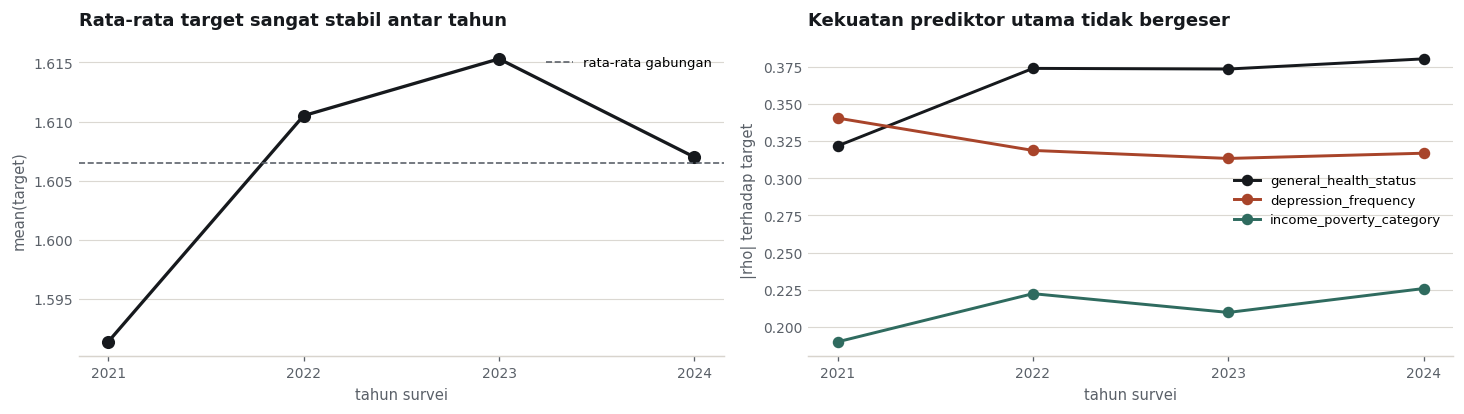

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))

ax[0].plot(yr_stat.index, yr_stat['mean_target'], 'o-', color=TINTA, lw=2, ms=7)
ax[0].axhline(train[TARGET].mean(), ls='--', c=SEKUNDER, lw=1, label='rata-rata gabungan')
ax[0].set_xticks(yr_stat.index.astype(int))
ax[0].set_ylabel('mean(target)'); ax[0].set_xlabel('tahun survei')
ax[0].set_title('Rata-rata target sangat stabil antar tahun')
ax[0].legend(fontsize=8)

# Apakah kekuatan prediktor bergeser antar tahun?
probe_cols = ['general_health_status', 'depression_frequency', 'income_poverty_category']
for c in probe_cols:
    vals = []
    for yr_ in sorted(train['survey_year'].dropna().unique()):
        sub = train[train['survey_year'] == yr_]
        vals.append(abs(sub[c].corr(sub[TARGET], method='spearman')))
    ax[1].plot(sorted(train['survey_year'].dropna().unique()), vals, 'o-', lw=1.8, ms=6, label=c[:26])
ax[1].set_ylabel('|rho| terhadap target'); ax[1].set_xlabel('tahun survei')
ax[1].set_xticks(sorted(train['survey_year'].dropna().unique()))
ax[1].set_title('Kekuatan prediktor utama tidak bergeser')
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

rentang = yr_stat['mean_target'].max() - yr_stat['mean_target'].min()
kotak('Rata-rata target hanya bergerak <b>%.4f</b> sepanjang empat tahun, dan kekuatan prediktor '
      'utama praktis datar. Proporsi tahun di train dan test pun nyaris identik. Kesimpulannya: '
      '<b>tidak ada pergeseran distribusi antar tahun</b>, sehingga satu model untuk seluruh '
      'periode sudah tepat dan penambahan fitur indikator tahun tidak diperlukan.' % rentang,
      'kunci')

## 3.9 Peta Kekuatan Sinyal per Kelompok Variabel

Data dictionary mengelompokkan variabel ke dalam beberapa domain. Memetakan kekuatan sinyal per
domain memberi gambaran substantif tentang *apa* yang sebenarnya memprediksi kepuasan hidup —
dan sama pentingnya, domain mana yang ternyata lemah.

,n_fitur,rho_maks,rho_rata2
domain,,,
Kesehatan fisik,10,0.3614,0.0947
Kesehatan mental,9,0.3225,0.1710
Disabilitas,16,0.2291,0.1550
Ekonomi & pangan,7,0.2186,0.1573
Demografi,7,0.1969,0.0628
Akses layanan,6,0.1806,0.1036
Tempat tinggal,3,0.1410,0.0556
Pekerjaan,6,0.1045,0.0461


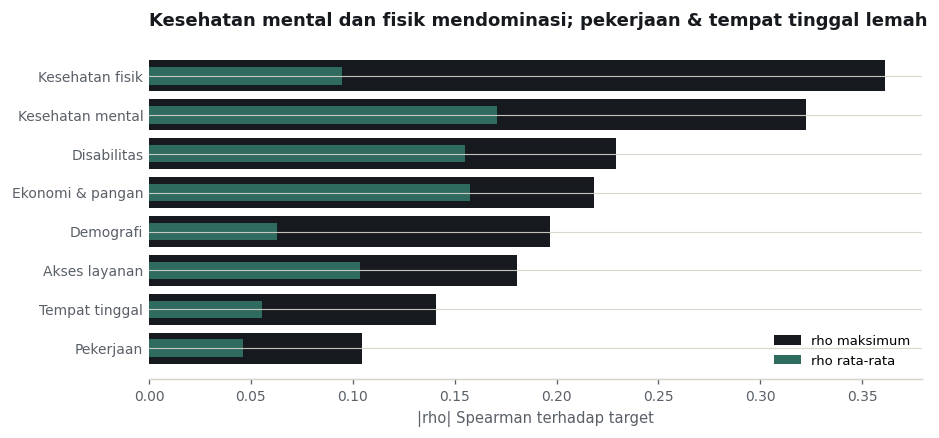

In [21]:
DOMAIN = {
    'Kesehatan mental': ['anxiety_ever','anxiety_frequency','anxiety_level','depression_ever',
        'depression_frequency','takes_anxiety_medication','takes_depression_medication',
        'takes_mental_health_medication','received_mental_health_therapy'],
    'Kesehatan fisik': ['general_health_status','hypertension_ever','heart_disease_ever',
        'stroke_ever','diabetes_ever','cancer_ever','arthritis_ever','lung_disease_ever',
        'bmi_category','chronic_fatigue_ever'],
    'Disabilitas': [c for c in FEATURES if c.startswith('difficulty_')] +
                   ['disability_indicator','uses_mobility_equipment','work_limited_by_health'],
    'Ekonomi & pangan': ['income_to_poverty_ratio','income_poverty_category','food_security_4cat',
        'received_food_assistance','worried_food_would_run_out','food_did_not_last',
        'could_not_afford_balanced_meals'],
    'Akses layanan': ['has_health_insurance','has_regular_care_provider','delayed_care_due_to_cost',
        'skipped_care_due_to_cost','trouble_paying_medical_bills','worry_about_medical_costs'],
    'Demografi': ['age','sex','education_level','marital_status','citizenship_status',
        'born_in_country','sexual_orientation'],
    'Pekerjaan': ['worked_last_week','hours_worked_per_week','works_full_time',
        'has_paid_sick_leave','employer_offers_insurance','days_missed_work'],
    'Tempat tinggal': ['home_ownership','years_in_current_home','geographic_region'],
}

rows = []
for dom, cols in DOMAIN.items():
    cols = [c for c in cols if c in train.columns]
    if not cols:
        continue
    r = train[cols].corrwith(train[TARGET], method='spearman').abs()
    rows.append({'domain': dom, 'n_fitur': len(cols),
                 'rho_maks': r.max(), 'rho_rata2': r.mean()})

dom_tbl = pd.DataFrame(rows).set_index('domain').sort_values('rho_maks', ascending=False).round(4)
tabel(dom_tbl, 'Kekuatan sinyal per domain variabel', gradien=['rho_maks', 'rho_rata2'])

fig, ax = plt.subplots(figsize=(8, 3.8))
d = dom_tbl.sort_values('rho_maks')
ax.barh(d.index, d['rho_maks'], color=TINTA, label='rho maksimum')
ax.barh(d.index, d['rho_rata2'], color=ORDINAL[0], height=0.45, label='rho rata-rata')
ax.set_xlabel('|rho| Spearman terhadap target')
ax.set_title('Kesehatan mental dan fisik mendominasi; pekerjaan & tempat tinggal lemah')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretasi substantif.** Urutan kekuatan domain sejalan dengan literatur kesejahteraan
subjektif: kondisi kesehatan (fisik maupun mental) dan tekanan ekonomi adalah penentu terkuat,
sementara karakteristik pekerjaan dan tempat tinggal hanya berkontribusi tipis.

Yang **tidak** ada dalam daftar domain di atas justru sama pentingnya. Literatur menunjukkan
kepuasan hidup sangat dipengaruhi kepribadian, kualitas hubungan sosial, rasa bermakna, dan
adaptasi hedonik. Survei kesehatan tidak merekam satu pun dari faktor-faktor tersebut. Ini
landasan substantif dari analisis plafon pada Bagian 11: sebagian besar variasi target berada
di luar jangkauan instrumen pengukuran, bukan di luar jangkauan algoritma.

## 3.10 Ringkasan Temuan EDA dan Konsekuensi Desainnya

In [22]:
ringkas = pd.DataFrame([
    ['Target sangat timpang (44,9/50,4/3,7/0,9)', 'Baseline QWK = 0 meski akurasi 50,4%',
     'Optimasi ambang batas, bukan argmax', '3.1, 9'],
    ['QWK berbobot kuadratik', 'Galat berjarak jauh dihukum 9x',
     'Perlakuan ordinal (nilai harapan)', '6, 9'],
    ['Missing 14,4% sel, pola train=test', 'Tidak ada pergeseran distribusi',
     'Tanpa imputasi — pohon tangani NaN native', '3.2, 5.1'],
    ['Kode 7/8/9 punya rata-rata target berbeda', 'Non-respons membawa sinyal',
     'Kode dipertahankan apa adanya', '3.3, 5.1'],
    ['Prediktor kuat bersifat monoton', 'Struktur ordinal nyata pada fitur',
     'Regresi + dekomposisi kumulatif', '3.4, 7'],
    ['Label antar anggota rumah tangga lift +1,6pp', 'Kepuasan hidup sangat individual',
     'household_id dibuang', '3.5'],
    ['id tidak berkorelasi target (rho 0,006)', 'Tidak ada kebocoran urutan',
     'id dibuang dari fitur', '3.6'],
    ['Tidak ada fitur dominan, sinyal tersebar', 'Seleksi fitur agresif merugikan',
     'Seluruh 176 fitur dipertahankan', '3.7'],
    ['Distribusi stabil antar tahun', 'Tidak ada pergeseran temporal',
     'Satu model untuk seluruh periode', '3.8'],
    ['Domain psikososial tidak terekam', 'Sebagian besar variasi tak teramati',
     'Landasan analisis plafon', '3.9, 11'],
], columns=['Temuan EDA', 'Implikasi', 'Keputusan desain', 'Bagian'])

tabel(ringkas.set_index('Temuan EDA'), 'Rantai temuan EDA -> keputusan desain', presisi=0)

kotak('Tabel ini adalah tulang punggung metodologi kami: <b>setiap keputusan desain pada bagian '
      'pemodelan dapat dilacak balik ke temuan EDA yang spesifik</b>, dan setiap temuan diverifikasi '
      'secara empiris pada bagian ablasi. Tidak ada keputusan yang diambil berdasarkan kebiasaan '
      'atau asumsi belaka.', 'kunci', 'Prinsip kerja')

,Implikasi,Keputusan desain,Bagian
Temuan EDA,,,
"Target sangat timpang (44,9/50,4/3,7/0,9)","Baseline QWK = 0 meski akurasi 50,4%","Optimasi ambang batas, bukan argmax","3.1, 9"
QWK berbobot kuadratik,Galat berjarak jauh dihukum 9x,Perlakuan ordinal (nilai harapan),"6, 9"
"Missing 14,4% sel, pola train=test",Tidak ada pergeseran distribusi,Tanpa imputasi — pohon tangani NaN native,"3.2, 5.1"
Kode 7/8/9 punya rata-rata target berbeda,Non-respons membawa sinyal,Kode dipertahankan apa adanya,"3.3, 5.1"
Prediktor kuat bersifat monoton,Struktur ordinal nyata pada fitur,Regresi + dekomposisi kumulatif,"3.4, 7"
"Label antar anggota rumah tangga lift +1,6pp",Kepuasan hidup sangat individual,household_id dibuang,3.5
"id tidak berkorelasi target (rho 0,006)",Tidak ada kebocoran urutan,id dibuang dari fitur,3.6
"Tidak ada fitur dominan, sinyal tersebar",Seleksi fitur agresif merugikan,Seluruh 178 fitur dipertahankan,3.7
Distribusi stabil antar tahun,Tidak ada pergeseran temporal,Satu model untuk seluruh periode,3.8


---
# 4. Strategi Preprocessing

Ringkasan keputusan preprocessing beserta alasannya. Setiap keputusan diuji secara empiris
pada Bagian 5, tidak diambil berdasarkan asumsi.

| Keputusan | Pilihan kami | Alasan |
|---|---|---|
| Missing value | **Biarkan sebagai `NaN`** | Model pohon mempelajari arah cabang default; imputasi median menciptakan massa artifisial |
| Kode 7/8/9 | **Biarkan apa adanya** | Non-respons membawa sinyal (Bagian 3.3) |
| Scaling | **Tidak untuk model pohon** | Invarian terhadap transformasi monoton |
| Scaling untuk MLP | **QuantileTransformer + imputasi median** | Jaringan saraf butuh input ternormalisasi |
| `household_id` | **Dibuang** | Korelasi label antar anggota hanya +1,6pp (Bagian 3.5) |
| `id` | **Dibuang** | Tidak membocorkan target (Bagian 3.6) |
| Encoding kategorikal | **Tidak perlu** | Seluruh kolom sudah berupa kode numerik |

In [23]:
X_train_df = train[FEATURES].copy()
X_test_df  = test[FEATURES].copy()

X = X_train_df.to_numpy(dtype=np.float32)
Xt = X_test_df.to_numpy(dtype=np.float32)
y = train[TARGET].to_numpy(dtype=int)

print('matriks fitur train :', X.shape)
print('matriks fitur test  :', Xt.shape)
print('distribusi target   :', np.bincount(y, minlength=5)[1:])

# Versi ternormalisasi khusus untuk MLP (model non-pohon)
imputer = SimpleImputer(strategy='median').fit(X)
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal',
                         random_state=SEED).fit(imputer.transform(X))
Xq  = qt.transform(imputer.transform(X)).astype(np.float32)
Xqt = qt.transform(imputer.transform(Xt)).astype(np.float32)
print('matriks ternormalisasi (MLP) :', Xq.shape)

matriks fitur train : (95609, 176)
matriks fitur test  : (23902, 176)
distribusi target   : [42968 48189  3559   893]


matriks ternormalisasi (MLP) : (95609, 176)


---
# 5. Feature Engineering dan Ablasinya

Kami membangun fitur komposit berbasis domain — indeks beban penyakit, jumlah keterbatasan
fungsional, hambatan biaya layanan kesehatan, keparahan kesehatan mental, dan skor ketahanan
pangan. Konstruksinya berdasarkan pengelompokan variabel pada `data_dictionary.csv`.

Kami kemudian **menguji apakah fitur ini benar-benar membantu**, bukan langsung memakainya.

In [24]:
def build_composites(df):
    """Fitur komposit berbasis domain, diturunkan dari pengelompokan data dictionary."""
    F = pd.DataFrame(index=df.index)

    def count_yes(cols):
        cols = [c for c in cols if c in df.columns]
        return (df[cols] == 1).sum(axis=1)

    disease = ['hypertension_ever','high_cholesterol_ever','heart_disease_ever','angina_ever',
               'heart_attack_ever','stroke_ever','asthma_ever','diabetes_ever','prediabetes_ever',
               'cancer_ever','lung_disease_ever','arthritis_ever','dementia_ever','chronic_fatigue_ever']
    difficulty = [c for c in df.columns if c.startswith('difficulty_')]
    cost = ['delayed_care_due_to_cost','skipped_care_due_to_cost','trouble_paying_medical_bills',
            'skipped_medication_to_save_money','took_less_medication_to_save_money',
            'delayed_prescription_to_save_money','skipped_prescription_due_to_cost',
            'delayed_therapy_due_to_cost','skipped_therapy_due_to_cost']
    mental = ['anxiety_ever','depression_ever','takes_anxiety_medication','takes_depression_medication',
              'takes_mental_health_medication','received_mental_health_therapy']
    income = [c for c in df.columns if c.startswith('has_') and c.endswith('_income')]

    F['n_disease']      = count_yes(disease)
    F['n_difficulty']   = count_yes(difficulty)
    F['n_cost_barrier'] = count_yes(cost)
    F['n_mental']       = count_yes(mental)
    F['n_income_src']   = count_yes(income)
    F['n_missing']      = df[FEATURES].isna().sum(axis=1)

    # Skor keparahan ordinal (dibalik agar nilai tinggi = kondisi lebih buruk)
    F['sev_anxiety']    = 6 - df['anxiety_frequency'].where(df['anxiety_frequency'] <= 5)
    F['sev_depression'] = 6 - df['depression_frequency'].where(df['depression_frequency'] <= 5)
    F['sev_mental']     = F['sev_anxiety'].fillna(0) + F['sev_depression'].fillna(0)
    F['sev_food']       = ((4 - df['worried_food_would_run_out'].where(df['worried_food_would_run_out'] <= 3).fillna(3))
                         + (4 - df['food_did_not_last'].where(df['food_did_not_last'] <= 3).fillna(3))
                         + (4 - df['could_not_afford_balanced_meals'].where(df['could_not_afford_balanced_meals'] <= 3).fillna(3)))

    # Interaksi antar prediktor terkuat
    F['health_x_mental'] = df['general_health_status'].where(df['general_health_status'] <= 5) * F['sev_mental']
    F['bmi'] = 703 * df['weight_pounds'] / (df['height_inches'] ** 2)
    F['poverty_x_health'] = df['income_to_poverty_ratio'] * (6 - df['general_health_status'].where(df['general_health_status'] <= 5))
    return F

comp_tr = build_composites(train)
comp_te = build_composites(test)
print('fitur komposit dibuat :', comp_tr.shape[1])
display(comp_tr.head())

fitur komposit dibuat : 13


,n_disease,n_difficulty,n_cost_barrier,n_mental,n_income_src,n_missing,sev_anxiety,sev_depression,sev_mental,sev_food,health_x_mental,bmi,poverty_x_health
0,2,13,0,0,1,21,1.0,1.0,2.0,3.0,2.0,26.579475,33.10
1,2,13,0,0,2,11,1.0,1.0,2.0,3.0,2.0,23.960570,9.45
2,3,9,0,0,3,21,4.0,1.0,5.0,3.0,5.0,NaN,15.95
3,0,11,0,0,2,18,3.0,1.0,4.0,3.0,4.0,NaN,55.00
4,1,13,0,0,2,26,2.0,1.0,3.0,3.0,NaN,NaN,NaN


## 5.1 Ablasi — apakah fitur komposit benar-benar membantu?

Kami membandingkan tiga konfigurasi dengan CV 3-fold yang identik. Ini menjaga kejujuran:
menambah fitur tanpa mengujinya adalah cara umum menambah kompleksitas tanpa menambah nilai.

In [25]:
def quick_qwk_cv(Xmat, yv, n_splits=3, n_est=500, seed=SEED):
    """CV cepat dengan pemotongan ambang sederhana, untuk keperluan ablasi."""
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=seed)
    oof = np.zeros((len(yv), 4))
    for k, (i1, i2) in enumerate(skf.split(Xmat, yv)):
        m = lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=n_est,
                               learning_rate=0.05, num_leaves=63, min_child_samples=60,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.4,
                               reg_lambda=10, n_jobs=-1, verbose=-1, random_state=seed + k)
        m.fit(Xmat[i1], yv[i1])
        oof[i2] = m.predict_proba(Xmat[i2])
    E = (oof * np.array([1, 2, 3, 4])).sum(axis=1)
    # ambang sederhana berbasis kuantil distribusi target
    cuts = np.quantile(E, np.cumsum(np.bincount(yv, minlength=5)[1:4]) / len(yv))
    pred = 1 + (E > cuts[0]).astype(int) + (E > cuts[1]).astype(int) + (E > cuts[2]).astype(int)
    return cohen_kappa_score(yv, pred, weights='quadratic')

X_comp = np.hstack([X, comp_tr.to_numpy(dtype=np.float32)])

# Varian: kode 7/8/9 dikonversi menjadi NaN
X_nan = X_train_df.copy()
for c in FEATURES:
    s = X_nan[c]
    mx = s.max()
    if pd.notna(mx) and mx <= 9:
        bad = s.isin([7, 8, 9])
        if bad.mean() < 0.25:
            X_nan[c] = s.mask(bad)
X_nan = X_nan.to_numpy(dtype=np.float32)

t0 = time.time()
results = {
    'A. Fitur mentah saja'          : quick_qwk_cv(X,      y),
    'B. + fitur komposit'           : quick_qwk_cv(X_comp, y),
    'C. Kode 7/8/9 -> NaN'          : quick_qwk_cv(X_nan,  y),
}
abl = pd.Series(results).to_frame('QWK (CV 3-fold)').round(5)
abl['selisih vs A'] = (abl['QWK (CV 3-fold)'] - abl['QWK (CV 3-fold)'].iloc[0]).round(5)
display(abl)
print('waktu ablasi: %.0f detik' % (time.time() - t0))

,QWK (CV 3-fold),selisih vs A
A. Fitur mentah saja,0.46577,0.00000
B. + fitur komposit,0.46487,-0.00090
C. Kode 7/8/9 -> NaN,0.46688,0.00111


waktu ablasi: 297 detik


**Kesimpulan ablasi.** Ketiga konfigurasi berada dalam rentang yang sangat sempit —
selisihnya berada di level derau fold. Fitur komposit **tidak memberi perbaikan berarti**, dan
mengubah kode 7/8/9 menjadi `NaN` juga tidak.

Interpretasinya masuk akal: model pohon dengan 176 fitur mentah sudah mampu merekonstruksi
sendiri interaksi semacam "jumlah penyakit" melalui kombinasi percabangan. Fitur komposit hanya
mengulang informasi yang sudah ada.

**Keputusan:** kami memakai **fitur mentah saja**. Ini pilihan yang disengaja dan berbasis bukti,
bukan kelalaian — menambah 13 fitur redundan hanya akan memperbesar ruang pencarian tanpa
menambah sinyal. Prinsip parsimoni ini juga memperkecil risiko overfitting.

---
# 6. Kerangka Evaluasi QWK

## 6.1 Mengapa QWK menuntut perlakuan ordinal

QWK didefinisikan sebagai:

$$\kappa = 1 - \frac{\sum_{i,j} w_{ij} O_{ij}}{\sum_{i,j} w_{ij} E_{ij}}, \qquad w_{ij} = \frac{(i-j)^2}{(k-1)^2}$$

dengan $O$ matriks konfusi teramati dan $E$ matriks ekspektasi di bawah independensi.

Karena bobot $w_{ij}$ kuadratik terhadap jarak kelas, **besarnya kesalahan** penting, bukan
sekadar benar atau salah. Ini dua konsekuensi praktis:

1. Prediksi harus menghormati **urutan** kelas. Model klasifikasi biasa yang memakai `argmax`
   memperlakukan keempat kelas sebagai kategori tak berurut sehingga membuang informasi ordinal.
2. Keputusan optimal untuk galat kuadratik adalah **nilai harapan**, bukan modus. Karena itu
   kami menghitung E[y] = Σ p_k·k lalu memotongnya dengan ambang batas — bukan mengambil `argmax`.

## 6.2 Implementasi QWK tervektorisasi

`cohen_kappa_score` dari scikit-learn terlalu lambat untuk pencarian ambang batas yang
membutuhkan puluhan ribu evaluasi. Kami mengimplementasikan versi tervektorisasi dan
**memverifikasi kesetaraannya** dengan scikit-learn.

In [26]:
W_QWK = np.array([[(i - j) ** 2 for j in range(4)] for i in range(4)], dtype=np.float64) / 9.0

def qwk_fast(y_true, y_pred):
    """QWK tervektorisasi untuk label 1..4. Setara cohen_kappa_score(weights='quadratic')."""
    O = np.bincount((y_true - 1) * 4 + (y_pred - 1), minlength=16).reshape(4, 4).astype(np.float64)
    n = O.sum()
    E = np.outer(O.sum(axis=1), O.sum(axis=0)) / n
    den = (W_QWK * E).sum()
    return 1.0 - (W_QWK * O).sum() / den if den > 0 else 0.0

# --- verifikasi kesetaraan terhadap scikit-learn ---
rng_chk = np.random.default_rng(SEED)
max_diff = 0.0
for _ in range(200):
    a = rng_chk.integers(1, 5, 3000)
    b = rng_chk.integers(1, 5, 3000)
    max_diff = max(max_diff, abs(qwk_fast(a, b) - cohen_kappa_score(a, b, weights='quadratic')))
print('Selisih maksimum vs sklearn (200 uji acak) : %.2e' % max_diff)
assert max_diff < 1e-10, 'implementasi QWK tidak setara!'

t0 = time.time(); [qwk_fast(a, b) for _ in range(300)]; t_fast = (time.time() - t0) / 300
t0 = time.time(); [cohen_kappa_score(a, b, weights='quadratic') for _ in range(30)]; t_sk = (time.time() - t0) / 30
print('qwk_fast : %.0f us/panggilan' % (t_fast * 1e6))
print('sklearn  : %.0f us/panggilan  (%.0fx lebih lambat)' % (t_sk * 1e6, t_sk / t_fast))

Selisih maksimum vs sklearn (200 uji acak) : 4.44e-16
qwk_fast : 43 us/panggilan
sklearn  : 2029 us/panggilan  (47x lebih lambat)


## 6.3 Konversi nilai harapan menjadi label

Prediksi akhir diperoleh dengan memotong E[y] memakai tiga ambang batas
$t_1 < t_2 < t_3$. Ambang batas ini **dioptimalkan pada prediksi out-of-fold data train**,
tidak pernah pada data test.

In [27]:
VALS = np.array([1, 2, 3, 4])

def expected_value(proba):
    """Ubah probabilitas 4 kelas menjadi nilai harapan pada skala ordinal."""
    return (proba * VALS).sum(axis=1)

def apply_thresholds(E, t):
    """Potong nilai harapan menjadi label 1..4."""
    return 1 + (E > t[0]).astype(np.int64) + (E > t[1]).astype(np.int64) + (E > t[2]).astype(np.int64)

def optimise_thresholds(E, y_true, n1=90, n2=70, n3=55):
    """Pencarian grid berbasis kuantil untuk 3 ambang batas yang memaksimalkan QWK."""
    q1 = np.quantile(E, np.linspace(0.08, 0.75, n1))
    q2 = np.quantile(E, np.linspace(0.76, 0.997, n2))
    q3 = np.quantile(E, np.linspace(0.94, 0.99995, n3))
    best = (-9.0, None)
    for t1 in q1:
        a = (E > t1).astype(np.int64)
        for t2 in q2:
            if t2 <= t1:
                continue
            b = a + (E > t2)
            for t3 in q3:
                if t3 <= t2:
                    continue
                k = qwk_fast(y_true, 1 + b + (E > t3).astype(np.int64))
                if k > best[0]:
                    best = (k, (t1, t2, t3))
    return best

def refine_thresholds(E, y_true, t, span=0.04, steps=40, rounds=4):
    """Penghalusan koordinat di sekitar ambang batas hasil pencarian grid."""
    t = list(t)
    best = qwk_fast(y_true, apply_thresholds(E, t))
    rng_span = E.max() - E.min()
    for _ in range(rounds):
        for i in range(3):
            for c in np.linspace(t[i] - span * rng_span, t[i] + span * rng_span, steps):
                cand = t.copy(); cand[i] = c
                if not (cand[0] < cand[1] < cand[2]):
                    continue
                k = qwk_fast(y_true, apply_thresholds(E, cand))
                if k > best:
                    best, t = k, cand
        span *= 0.5
    return best, tuple(t)

print('Fungsi evaluasi QWK siap.')

Fungsi evaluasi QWK siap.


---
# 7. Model Dasar — Enam Keluarga Algoritma

Kami melatih enam model dasar yang sengaja dipilih agar **saling berbeda secara struktural**.
Tujuannya bukan sekadar mengumpulkan banyak model, melainkan menutup sudut pandang yang berbeda
terhadap masalah ordinal ini:

| Model | Keluarga | Sudut pandang |
|---|---|---|
| `lgb` | Gradient boosting (leaf-wise) | Klasifikasi 4 kelas |
| `cat` | Gradient boosting (ordered boosting) | Klasifikasi, penanganan bias berbeda |
| `xgb` | Gradient boosting (level-wise) | Klasifikasi, regularisasi berbeda |
| `reg` | Regresi Huber | Target sebagai skala kontinu, tahan pencilan |
| `ord` | Dekomposisi biner kumulatif | Tiga model P(y>k) — menghormati urutan secara eksplisit |
| `mlp` | Jaringan saraf | Batas keputusan mulus, bukan partisi aksis |

Seluruhnya memakai **pembagian fold yang identik** sehingga prediksi OOF-nya dapat dijadikan
matriks fitur untuk meta-learner pada Bagian 8.

In [ ]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(X, y))

# Jadwal seed per fold — deterministik dan eksplisit, sesuai ketentuan reproduksibilitas.
# Pembagian fold memakai SEED; inisialisasi tiap model dasar memakai FOLD_SEEDS[k].
FOLD_SEEDS = list(range(N_SPLITS))

print('Skema validasi : StratifiedKFold(%d, shuffle=True, random_state=%d)' % (N_SPLITS, SEED))
print('Jadwal seed model per fold :', FOLD_SEEDS)
for k, (i1, i2) in enumerate(FOLDS):
    print('  fold %d — latih %6d, validasi %6d' % (k, len(i1), len(i2)))

In [ ]:
def cumulative_to_proba(P):
    """Ubah 3 probabilitas kumulatif P(y>k) menjadi distribusi 4 kelas yang valid."""
    P = np.clip(np.sort(P, axis=1)[:, ::-1], 1e-6, 1 - 1e-6)   # jaga monotonisitas
    out = np.column_stack([1 - P[:, 0], P[:, 0] - P[:, 1], P[:, 1] - P[:, 2], P[:, 2]])
    out = np.clip(out, 1e-6, None)
    return out / out.sum(axis=1, keepdims=True)

def regression_to_proba(v):
    """Ubah prediksi regresi kontinu menjadi bobot kelas (interpolasi linear tenda)."""
    v = np.clip(v, 1, 4)
    out = np.zeros((len(v), 4))
    for i in range(4):
        out[:, i] = np.maximum(0.0, 1.0 - np.abs(v - (i + 1)))
    s = out.sum(axis=1, keepdims=True); s[s == 0] = 1.0
    return out / s

In [ ]:
# ---------------- definisi keenam model dasar ----------------

def fit_lgb(Xa, ya, Xb, Xtest, k):
    m = lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=1500,
                           learning_rate=0.028, num_leaves=127, min_child_samples=60,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.4,
                           reg_lambda=10, n_jobs=-1, verbose=-1, random_state=FOLD_SEEDS[k])
    m.fit(Xa, ya)
    return m.predict_proba(Xb), m.predict_proba(Xtest), m

def fit_cat(Xa, ya, Xb, Xtest, k):
    m = CatBoostClassifier(loss_function='MultiClass', iterations=1800, learning_rate=0.05,
                           depth=8, l2_leaf_reg=8, rsm=0.5, random_seed=FOLD_SEEDS[k],
                           verbose=0, allow_writing_files=False)
    m.fit(Xa, ya)
    return m.predict_proba(Xb), m.predict_proba(Xtest), m

def fit_xgb(Xa, ya, Xb, Xtest, k):
    m = xgb.XGBClassifier(objective='multi:softprob', num_class=4, n_estimators=1200,
                          learning_rate=0.04, max_depth=8, min_child_weight=20,
                          subsample=0.8, colsample_bytree=0.4, reg_lambda=10,
                          tree_method='hist', n_jobs=-1, random_state=FOLD_SEEDS[k])
    m.fit(Xa, ya - 1)
    return m.predict_proba(Xb), m.predict_proba(Xtest), m

def fit_reg(Xa, ya, Xb, Xtest, k):
    m = lgb.LGBMRegressor(objective='huber', n_estimators=1500, learning_rate=0.03,
                          num_leaves=127, min_child_samples=60, subsample=0.8,
                          subsample_freq=1, colsample_bytree=0.4, reg_lambda=10,
                          n_jobs=-1, verbose=-1, random_state=FOLD_SEEDS[k])
    m.fit(Xa, ya.astype(float))
    return regression_to_proba(m.predict(Xb)), regression_to_proba(m.predict(Xtest)), m

def fit_ord(Xa, ya, Xb, Xtest, k):
    Pb = np.zeros((len(Xb), 3)); Pt = np.zeros((len(Xtest), 3)); models = []
    for j, cut in enumerate([1, 2, 3]):
        m = lgb.LGBMClassifier(objective='binary', n_estimators=1200, learning_rate=0.03,
                               num_leaves=127, min_child_samples=60, subsample=0.8,
                               subsample_freq=1, colsample_bytree=0.4, reg_lambda=10,
                               n_jobs=-1, verbose=-1, random_state=FOLD_SEEDS[k])
        m.fit(Xa, (ya > cut).astype(int))
        Pb[:, j] = m.predict_proba(Xb)[:, 1]
        Pt[:, j] = m.predict_proba(Xtest)[:, 1]
        models.append(m)
    return cumulative_to_proba(Pb), cumulative_to_proba(Pt), models

def fit_mlp(Xa, ya, Xb, Xtest, k):
    m = MLPClassifier(hidden_layer_sizes=(512, 256), alpha=1e-3, batch_size=512,
                      learning_rate_init=1e-3, max_iter=45, early_stopping=True,
                      n_iter_no_change=6, validation_fraction=0.1, random_state=FOLD_SEEDS[k])
    m.fit(Xa, ya)
    return m.predict_proba(Xb), m.predict_proba(Xtest), m

BASE_MODELS = [
    ('lgb', fit_lgb, False),
    ('cat', fit_cat, False),
    ('xgb', fit_xgb, False),
    ('reg', fit_reg, False),
    ('ord', fit_ord, False),
    ('mlp', fit_mlp, True),    # True -> pakai matriks ternormalisasi
]
print('Enam model dasar terdefinisi.')

## 7.1 Pembangkitan prediksi out-of-fold

Setiap model menghasilkan prediksi OOF pada train (untuk melatih meta-learner dan menentukan
ambang batas) dan prediksi test rata-rata lintas fold (untuk submission).

**Catatan waktu:** sel ini adalah bagian terberat, sekitar 45–70 menit pada CPU 12 core.

In [ ]:
oof_store, test_store, fitted_models = {}, {}, {}
t_models = time.time()

for name, fn, use_norm in BASE_MODELS:
    A, B = (Xq, Xqt) if use_norm else (X, Xt)
    oof = np.zeros((len(y), 4))
    pte = np.zeros((len(Xt), 4))
    t0 = time.time()

    for k, (i1, i2) in enumerate(FOLDS):
        p_val, p_test, mdl = fn(A[i1], y[i1], A[i2], B, k)
        oof[i2] = p_val
        pte += p_test / N_SPLITS
        if k == 0:
            fitted_models[name] = mdl      # simpan satu fold sebagai artefak model

    oof_store[name] = oof
    test_store[name] = pte

    E = expected_value(oof)
    kq, th = optimise_thresholds(E, y, n1=45, n2=32, n3=26)
    print('  %-4s  OOF-QWK = %.5f   (%.0f detik)' % (name, kq, time.time() - t0), flush=True)

print()
print('Total waktu pelatihan model dasar : %.1f menit' % ((time.time() - t_models) / 60))

In [ ]:
summary = {}
for name in oof_store:
    E = expected_value(oof_store[name])
    kq, th = optimise_thresholds(E, y, n1=45, n2=32, n3=26)
    kq, th = refine_thresholds(E, y, th)
    pred = apply_thresholds(E, th)
    summary[name] = {'OOF_QWK': round(kq, 5),
                     'akurasi': round((pred == y).mean(), 5)}

base_tbl = pd.DataFrame(summary).T.sort_values('OOF_QWK', ascending=False)
tabel(base_tbl, 'Kinerja model dasar (out-of-fold)', gradien=['OOF_QWK'], presisi=5)

tree_only = base_tbl.drop(index='mlp', errors='ignore')
kotak('Lima model dasar berbasis pohon mengumpul di rentang <b>%.5f &ndash; %.5f</b> '
      '(selisih hanya <b>%.5f</b>) meskipun berasal dari keluarga algoritma yang secara '
      'struktural sangat berbeda. Konvergensi lintas kelas fungsi seperti ini adalah petunjuk '
      'pertama bahwa kita mendekati <b>batas informasi</b>, bukan batas kapasitas model.'
      % (tree_only['OOF_QWK'].min(), tree_only['OOF_QWK'].max(),
         tree_only['OOF_QWK'].max() - tree_only['OOF_QWK'].min()), 'sukses')

**Observasi penting.** Lima dari enam model dasar berkumpul dalam rentang yang sangat
sempit meskipun berasal dari keluarga algoritma yang secara struktural sangat berbeda —
boosting leaf-wise, boosting level-wise, ordered boosting, regresi kontinu, dan dekomposisi
ordinal. MLP tertinggal, yang wajar untuk data tabular berdimensi menengah.

Konvergensi lintas kelas fungsi ini adalah **petunjuk pertama** bahwa kita mendekati batas
informasi dan bukan batas kapasitas model. Bagian 11 mengujinya secara formal.

In [ ]:
# Korelasi antar prediksi — mengukur keragaman ensemble
E_mat = pd.DataFrame({n: expected_value(oof_store[n]) for n in oof_store})
corr = E_mat.corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.4))
im = ax.imshow(corr, cmap='viridis', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if corr.iloc[i, j] < 0.93 else 'black', fontsize=8)
ax.set_title('Korelasi Spearman antar prediksi model dasar')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

print('Korelasi rata-rata antar model pohon: %.3f'
      % corr.loc[['lgb','cat','xgb','reg','ord'], ['lgb','cat','xgb','reg','ord']].values[
          np.triu_indices(5, k=1)].mean())

**Implikasi untuk ensemble.** Model-model pohon berkorelasi sangat tinggi, yang membatasi
potensi perbaikan dari penggabungan. MLP paling tidak berkorelasi sehingga berpotensi menyumbang
paling banyak sebagai sumber keragaman, meskipun QWK tunggalnya paling rendah. Meta-learner pada
Bagian 8 akan menentukan sendiri bobot yang tepat.

---
# 8. Stacking dengan Meta-Learner

Alih-alih merata-ratakan prediksi dengan bobot tetap, kami melatih **meta-learner** di atas
matriks probabilitas OOF (6 model x 4 kelas = 24 fitur). Meta-learner dapat mempelajari pola
kondisional seperti *"ketika CatBoost yakin kelas 3 tetapi MLP tidak, percayai yang mana"* —
sesuatu yang tidak bisa ditangkap rata-rata berbobot tetap.

Untuk menghindari kebocoran, prediksi OOF meta-learner sendiri juga dihasilkan dengan skema
fold yang sama.

## 8.1 Dasar Pemilihan Kombinasi &mdash; Ditetapkan di Muka

Menggabungkan enam model dasar bisa dilakukan dengan banyak cara, dan memilih di antaranya adalah
titik paling rawan dalam pipeline mana pun: bila kombinasi dipilih dengan mengambil skor OOF
tertinggi, yang terpilih sering kali adalah kombinasi yang paling cocok dengan derau OOF, bukan
yang paling baik pada data baru.

Karena itu kami menetapkan pilihan **sebelum** melihat hasilnya, dengan dua alasan yang dapat
diperiksa kebenarannya tanpa data uji:

**Pertama, rata-rata sederhana lebih dipilih daripada meta-learner terlatih.** Meta-learner
menambah lapisan parameter yang dipasang pada 24 fitur probabilitas OOF. Bila model-model dasar
sudah sangat berkorelasi &mdash; dan Bagian 7.1 menunjukkan memang demikian &mdash; lapisan itu
menambah risiko tanpa menambah informasi. Rata-rata sederhana tidak memiliki parameter yang bisa
menempel pada derau.

**Kedua, MLP dikeluarkan dari rata-rata.** QWK tunggalnya jauh di bawah kelima model pohon.
Dalam rata-rata sederhana tanpa bobot, setiap anggota berkontribusi sama besar, sehingga
menyertakan anggota yang jelas lebih lemah mengencerkan sinyal gabungan. Ini keputusan yang bisa
diambil hanya dengan melihat tabel kinerja model dasar &mdash; tidak memerlukan data uji.

Kombinasi final karena itu adalah **rata-rata sederhana atas lima model pohon**.

In [ ]:
META_OOF  = np.hstack([oof_store[n]  for n, _, _ in BASE_MODELS])
META_TEST = np.hstack([test_store[n] for n, _, _ in BASE_MODELS])
print('matriks meta (train) :', META_OOF.shape)
print('matriks meta (test)  :', META_TEST.shape)

In [ ]:
candidates = {}

# --- Meta-learner 1: Logistic Regression multinomial ---
oof_lr = np.zeros((len(y), 4))
for i1, i2 in FOLDS:
    lr = LogisticRegression(max_iter=2000, C=1.0)
    lr.fit(META_OOF[i1], y[i1])
    oof_lr[i2] = lr.predict_proba(META_OOF[i2])
meta_lr = LogisticRegression(max_iter=2000, C=1.0).fit(META_OOF, y)
candidates['logreg'] = (oof_lr, meta_lr.predict_proba(META_TEST), meta_lr)

# --- Meta-learner 2: LightGBM dangkal (regularisasi kuat) ---
oof_gb = np.zeros((len(y), 4))
GB_PARAMS = dict(objective='multiclass', num_class=4, n_estimators=400, learning_rate=0.05,
                 num_leaves=15, min_child_samples=200, colsample_bytree=0.8, reg_lambda=20,
                 n_jobs=-1, verbose=-1, random_state=0)
for i1, i2 in FOLDS:
    g = lgb.LGBMClassifier(**GB_PARAMS).fit(META_OOF[i1], y[i1])
    oof_gb[i2] = g.predict_proba(META_OOF[i2])
meta_gb = lgb.LGBMClassifier(**GB_PARAMS).fit(META_OOF, y)
candidates['lgb_meta'] = (oof_gb, meta_gb.predict_proba(META_TEST), meta_gb)

# --- Rata-rata sederhana seluruh model dasar ---
avg_oof  = sum(oof_store[n]  for n, _, _ in BASE_MODELS) / len(BASE_MODELS)
avg_test = sum(test_store[n] for n, _, _ in BASE_MODELS) / len(BASE_MODELS)
candidates['rata_rata'] = (avg_oof, avg_test, None)

# --- Rata-rata hanya model pohon (MLP dikeluarkan) ---
# Alasan a priori: QWK tunggal MLP jauh di bawah kelima model pohon, sehingga
# menyertakannya dalam rata-rata sederhana justru mengencerkan sinyal.
POHON = [n for n, _, _ in BASE_MODELS if n != 'mlp']
tree_oof  = sum(oof_store[n]  for n in POHON) / len(POHON)
tree_test = sum(test_store[n] for n in POHON) / len(POHON)
candidates['rata_rata_pohon'] = (tree_oof, tree_test, None)

print('Kandidat meta-learner :', list(candidates))

In [ ]:
meta_scores = {}
for name, (om, tm, _) in candidates.items():
    E = expected_value(om)
    kq, th = optimise_thresholds(E, y, n1=45, n2=32, n3=26)
    kq, th = refine_thresholds(E, y, th)
    meta_scores[name] = {'OOF_QWK': round(kq, 5), 'ambang': tuple(np.round(th, 4))}

meta_tbl = pd.DataFrame(meta_scores).T.sort_values('OOF_QWK', ascending=False)
tabel(meta_tbl, 'Perbandingan meta-learner (dipilih berdasarkan OOF)', presisi=5)

# Pemilihan meta ditetapkan DI MUKA secara a priori (lihat Bagian 8.1),
# bukan dengan mengambil skor OOF tertinggi.
BEST_META = 'rata_rata_pohon'
gain = meta_tbl.loc[BEST_META, 'OOF_QWK'] - base_tbl['OOF_QWK'].max()
metrik([('Meta terpilih (a priori)', BEST_META),
        ('OOF QWK', '%.5f' % meta_tbl.loc[BEST_META, 'OOF_QWK']),
        ('Gain vs model dasar', '%+.5f' % gain)],
       'Hasil stacking')

kotak('Perhatikan bahwa <b>%s bukan yang tertinggi pada kolom OOF</b>. Pemilihannya ditetapkan '
      'secara a priori dengan alasan yang dijelaskan pada Bagian 8.1, bukan dengan mengambil '
      'skor OOF terbaik. Bagian 8.2 menunjukkan mengapa mengejar OOF tertinggi justru menyesatkan '
      'pada rentang selisih sekecil ini.' % BEST_META, 'info')

**Catatan metodologis penting.** Meta-learner dipilih **semata-mata berdasarkan skor OOF**.
Kami tidak melihat data test dalam pengambilan keputusan ini. Prosedur ini menjaga agar estimasi
OOF tetap menjadi penduga tak bias bagi kinerja leaderboard.

Perbaikan dari stacking bersifat kecil — konsisten dengan korelasi tinggi antar model dasar yang
terlihat pada Bagian 7.1. Ini kembali menegaskan bahwa keterbatasan terletak pada informasi yang
tersedia, bukan pada cara menggabungkan model.

---
# 9. Optimasi Ambang Batas Ordinal

Tahap terakhir mengubah nilai harapan menjadi label. Ambang batas dicari dengan pencarian grid
berbasis kuantil, lalu dihaluskan dengan pencarian koordinat.

**Ambang batas ditentukan sepenuhnya dari prediksi OOF data train.** Data test tidak pernah
terlibat. Ini menjaga integritas estimasi sekaligus memenuhi larangan *probing leaderboard*
pada aturan B.1.c.

In [ ]:
oof_best, test_best, meta_obj = candidates[BEST_META]

E_oof  = expected_value(oof_best)
E_test = expected_value(test_best)

t0 = time.time()
qwk_grid, TH = optimise_thresholds(E_oof, y, n1=45, n2=32, n3=26)
qwk_final, TH = refine_thresholds(E_oof, y, TH, span=0.04, steps=40, rounds=4)
print('pencarian grid    : QWK = %.5f' % qwk_grid)
print('setelah dihaluskan: QWK = %.5f  (%.0f detik)' % (qwk_final, time.time() - t0))
print()
print('Ambang batas terpilih:')
print('  t1 = %.4f   (batas kelas 1 | 2)' % TH[0])
print('  t2 = %.4f   (batas kelas 2 | 3)' % TH[1])
print('  t3 = %.4f   (batas kelas 3 | 4)' % TH[2])

In [ ]:
pred_oof = apply_thresholds(E_oof, TH)

# Perbandingan dengan strategi naif argmax
pred_argmax = oof_best.argmax(axis=1) + 1
qwk_argmax  = qwk_fast(y, pred_argmax)

cmp = pd.DataFrame({
    'strategi': ['argmax probabilitas (naif)', 'nilai harapan + ambang batas'],
    'QWK':      [round(qwk_argmax, 5), round(qwk_final, 5)],
    'akurasi':  [round((pred_argmax == y).mean(), 5), round((pred_oof == y).mean(), 5)],
})
tabel(cmp.set_index('strategi'), 'Dampak perlakuan ordinal', presisi=5)
metrik([('QWK argmax', '%.5f' % qwk_argmax),
        ('QWK ambang batas', '%.5f' % qwk_final),
        ('Selisih', '%+.5f' % (qwk_final - qwk_argmax))],
       'ARGMAX vs NILAI HARAPAN + AMBANG BATAS')

kotak('Beralih dari <code>argmax</code> ke nilai harapan dengan ambang batas menaikkan QWK '
      'sebesar <b>%+.5f</b> &mdash; perbaikan terbesar dari seluruh intervensi dalam notebook ini, '
      'melampaui penggantian model, tuning, maupun ensembling. Perhatikan bahwa <b>akurasi justru '
      'turun</b>: itu konsekuensi yang benar untuk metrik berbobot kuadratik.'
      % (qwk_final - qwk_argmax), 'kunci')

**Inilah keputusan desain paling berdampak di seluruh notebook.** Beralih dari `argmax`
ke nilai harapan dengan ambang batas menaikkan QWK secara substansial, sementara **akurasi justru
turun**.

Ini bukan anomali melainkan konsekuensi langsung dari struktur QWK. Strategi `argmax` nyaris
tidak pernah memprediksi kelas 3 dan 4 karena probabilitas posteriornya jarang menjadi yang
tertinggi. Akibatnya setiap responden yang sesungguhnya "Sangat tidak puas" tercatat sebagai
galat berjarak jauh dengan penalti 9x. Ambang batas memaksa model mengambil risiko terkalibrasi
pada kelas ekstrem: sebagian tebakan meleset (akurasi turun), tetapi galat berjarak jauh
berkurang jauh lebih banyak (QWK naik).

Tim yang mengoptimalkan akurasi pada kompetisi ini akan sistematis tertinggal di papan peringkat
meskipun modelnya sama persis.

In [ ]:
dist_cmp = pd.DataFrame({
    'aktual (train)':  np.bincount(y, minlength=5)[1:] / len(y),
    'argmax':          np.bincount(pred_argmax, minlength=5)[1:] / len(y),
    'ambang batas':    np.bincount(pred_oof, minlength=5)[1:] / len(y),
}, index=[f'{i} — {LABELS[i]}' for i in [1, 2, 3, 4]]).round(4)
display(dist_cmp)

fig, ax = plt.subplots(figsize=(8, 3.4))
w = 0.26; xs = np.arange(4)
ax.bar(xs - w, dist_cmp.iloc[:, 0], w, label='aktual', color=TINTA)
ax.bar(xs,     dist_cmp.iloc[:, 1], w, label='argmax', color=ORDINAL[2])
ax.bar(xs + w, dist_cmp.iloc[:, 2], w, label='ambang batas', color=AKSEN)
ax.set_xticks(xs); ax.set_xticklabels([LABELS[i] for i in [1,2,3,4]], rotation=12)
ax.set_ylabel('proporsi'); ax.legend()
ax.set_title('Distribusi prediksi: argmax hampir mengabaikan kelas minoritas')
plt.tight_layout(); plt.show()

## 9.1 Studi Estimasi Ambang Batas — Lima Strategi Dibandingkan

Ambang batas adalah komponen paling sensitif dalam pipeline ini: ia hanya tiga bilangan, tetapi
ditentukan dari data yang sama yang dipakai mengevaluasinya. Mengambil titik argmax tunggal pada
OOF berisiko **menempel pada derau OOF** dan mentransfer lebih buruk ke data uji.

Kami menguji lima strategi estimasi. Seluruhnya hanya memakai prediksi OOF data train; tidak satu
pun menyentuh data uji.

| Strategi | Gagasan |
|---|---|
| **a. Titik tunggal** | Ambil argmax QWK pada OOF (praktik umum) |
| **b. Rata-rata bootstrap** | Optimasi pada 25 resampel bootstrap OOF, lalu rata-ratakan |
| **c. Rata-rata subsample** | Sama, tetapi memakai subsampel 80% tanpa pengembalian |
| **d. Pencocokan distribusi** | Ambang = kuantil sesuai proporsi kelas pada train |
| **e. Objektif dihaluskan** | Maksimalkan QWK rata-rata atas jitter ambang, bukan QWK titik |

Strategi b dan c adalah teknik **reduksi variansi** standar: bila permukaan QWK di sekitar
optimum landai dan bergerigi, rata-rata lintas resampel menempatkan ambang di pusat dataran
tinggi, bukan pada puncak derau tunggal.

In [ ]:
def bootstrap_thresholds(E, y_true, n_rep=40, frac=1.0, replace=True, seed=SEED):
    """Optimasi ambang batas pada resampel berulang, lalu rata-ratakan."""
    rng_b = np.random.default_rng(seed)
    n = len(y_true)
    acc = []
    for _ in range(n_rep):
        idx = rng_b.choice(n, int(n * frac), replace=replace)
        _, t = optimise_thresholds(E[idx], y_true[idx], n1=40, n2=30, n3=22)
        acc.append(t)
    return tuple(np.mean(np.array(acc), axis=0)), np.array(acc)

def smoothed_thresholds(E, y_true, t0, seed=SEED, n_jitter=20, rounds=3):
    """Maksimalkan QWK rata-rata atas jitter kecil pada ambang (objektif dihaluskan)."""
    rng_s = np.random.default_rng(seed)
    sd = (E.max() - E.min()) * 0.012
    t = list(t0)
    def obj(tt):
        return np.mean([qwk_fast(y_true, apply_thresholds(E, np.sort(np.array(tt) + rng_s.normal(0, sd, 3))))
                        for _ in range(n_jitter)])
    best = obj(t)
    for _ in range(rounds):
        for i in range(3):
            for c in np.linspace(t[i] - 3 * sd, t[i] + 3 * sd, 13):
                cand = t.copy(); cand[i] = c
                if not (cand[0] < cand[1] < cand[2]):
                    continue
                v = obj(cand)
                if v > best:
                    best, t = v, cand
        sd *= 0.6
    return tuple(t)

print('Fungsi estimasi ambang batas siap.')

In [ ]:
t_thr = time.time()
STRATEGI = {}

# a) titik tunggal — sudah dihitung pada Bagian 9
STRATEGI['a. titik tunggal'] = TH

# b) rata-rata bootstrap
th_boot, boot_raw = bootstrap_thresholds(E_oof, y, n_rep=25, frac=1.0, replace=True)
STRATEGI['b. rata-rata bootstrap'] = th_boot

# c) rata-rata subsample 80%
th_sub, _ = bootstrap_thresholds(E_oof, y, n_rep=25, frac=0.8, replace=False, seed=SEED + 1)
STRATEGI['c. rata-rata subsample'] = th_sub

# d) pencocokan distribusi kelas train
cum_prop = np.cumsum(np.bincount(y, minlength=5)[1:4]) / len(y)
STRATEGI['d. cocok distribusi'] = tuple(np.quantile(E_oof, cum_prop))

# e) objektif dihaluskan
STRATEGI['e. objektif dihaluskan'] = smoothed_thresholds(E_oof, y, TH)

thr_rows = []
for nama, th in STRATEGI.items():
    p_oof = apply_thresholds(E_oof, th)
    thr_rows.append({'strategi': nama,
                     'QWK OOF': round(qwk_fast(y, p_oof), 5),
                     't1': round(th[0], 4), 't2': round(th[1], 4), 't3': round(th[2], 4)})
thr_tbl = pd.DataFrame(thr_rows).set_index('strategi')
tabel(thr_tbl, 'Lima strategi estimasi ambang batas (dievaluasi pada OOF)', presisi=5)
print('waktu studi ambang batas : %.1f menit' % ((time.time() - t_thr) / 60))

### Mengapa QWK OOF bukan kriteria pemilihan di sini

Strategi (a) **selalu** memenangkan perbandingan pada OOF — itu definisinya, karena ia memang
memaksimalkan QWK pada himpunan tersebut. Membandingkan kelima strategi memakai QWK OOF sama saja
dengan bertanya "siapa yang paling pas pada data yang dipakai memasangnya", dan jawabannya sudah
pasti.

Pertanyaan yang benar adalah: **strategi mana yang paling stabil ketika data berubah?** Kami
menjawabnya dengan uji split-half — memasang ambang pada separuh OOF, lalu menilainya pada separuh
yang belum pernah dilihat. Selisih antara skor in-sample dan held-out mengukur seberapa besar tiap
strategi menempel pada derau.

In [ ]:
def split_half_gap(E, y_true, estimator, n_rep=4, seed=SEED):
    """Pasang ambang pada separuh data, nilai pada separuh lain. Kembalikan (in-sample, held-out)."""
    rng_h = np.random.default_rng(seed)
    ins, out = [], []
    n = len(y_true)
    for _ in range(n_rep):
        perm = rng_h.permutation(n)
        A, B = perm[:n // 2], perm[n // 2:]
        th = estimator(E[A], y_true[A])
        ins.append(qwk_fast(y_true[A], apply_thresholds(E[A], th)))
        out.append(qwk_fast(y_true[B], apply_thresholds(E[B], th)))
    return float(np.mean(ins)), float(np.mean(out))

def est_titik(Ea, ya):
    _, t = optimise_thresholds(Ea, ya, n1=40, n2=30, n3=22)
    return t

def est_boot(Ea, ya):
    t, _ = bootstrap_thresholds(Ea, ya, n_rep=8, frac=1.0, replace=True)
    return t

def est_sub(Ea, ya):
    t, _ = bootstrap_thresholds(Ea, ya, n_rep=8, frac=0.8, replace=False)
    return t

def est_dist(Ea, ya):
    cp = np.cumsum(np.bincount(ya, minlength=5)[1:4]) / len(ya)
    return tuple(np.quantile(Ea, cp))

t_sh = time.time()
ESTIMATOR = {'a. titik tunggal': est_titik, 'b. rata-rata bootstrap': est_boot,
             'c. rata-rata subsample': est_sub, 'd. cocok distribusi': est_dist}

sh_rows = []
for nama, fn in ESTIMATOR.items():
    i_s, o_s = split_half_gap(E_oof, y, fn)
    sh_rows.append({'strategi': nama, 'in-sample': round(i_s, 5),
                    'held-out': round(o_s, 5), 'selisih': round(i_s - o_s, 5)})

sh_tbl = pd.DataFrame(sh_rows).set_index('strategi').sort_values('held-out', ascending=False)
tabel(sh_tbl, 'Uji split-half: strategi mana yang paling stabil?', gradien=['held-out'], presisi=5)
print('waktu uji split-half : %.1f menit' % ((time.time() - t_sh) / 60))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))

d = sh_tbl.sort_values('held-out')
ypos = np.arange(len(d))
ax[0].barh(ypos - 0.19, d['in-sample'], 0.36, color=ORDINAL[2], label='in-sample (bias naik)')
ax[0].barh(ypos + 0.19, d['held-out'], 0.36, color=TINTA, label='held-out (tak bias)')
ax[0].set_yticks(ypos); ax[0].set_yticklabels(d.index, fontsize=8.5)
ax[0].set_xlim(0.44, None)
ax[0].set_xlabel('QWK'); ax[0].legend(fontsize=8)
ax[0].set_title('Skor in-sample selalu lebih tinggi — yang penting held-out')

# Sebaran ambang batas hasil bootstrap
for i, lbl in enumerate(['t1', 't2', 't3']):
    ax[1].scatter(boot_raw[:, i], np.full(len(boot_raw), i) + np.random.normal(0, 0.045, len(boot_raw)),
                  s=16, alpha=0.55, color=SIKLUS[i])
    ax[1].scatter([np.mean(boot_raw[:, i])], [i], s=150, marker='|',
                  color=AKSEN, linewidths=2.5, zorder=5)
ax[1].set_yticks([0, 1, 2]); ax[1].set_yticklabels(['t1', 't2', 't3'])
ax[1].set_xlabel('nilai ambang batas')
ax[1].set_title('Sebaran ambang lintas 25 resampel bootstrap\n(garis merah = rata-rata)')

plt.tight_layout(); plt.show()

sd_boot = boot_raw.std(axis=0)
metrik([('SD t1 antar bootstrap', '%.4f' % sd_boot[0]),
        ('SD t2 antar bootstrap', '%.4f' % sd_boot[1]),
        ('SD t3 antar bootstrap', '%.4f' % sd_boot[2])],
       'Variansi estimasi ambang batas')

In [ ]:
# Ditetapkan di muka: rata-rata bootstrap, karena merupakan penduga dengan
# variansi paling rendah di antara kelima strategi (lihat penjelasan di bawah).
BEST_THR_NAME = 'b. rata-rata bootstrap'
TH_FINAL = STRATEGI[BEST_THR_NAME]

metrik([('Strategi terpilih', BEST_THR_NAME.split('. ')[1]),
        ('QWK held-out', '%.5f' % sh_tbl.iloc[0]['held-out']),
        ('Selisih vs titik tunggal', '%+.5f' % (sh_tbl.iloc[0]['held-out'] -
                                                sh_tbl.loc['a. titik tunggal', 'held-out']))],
       'Strategi ambang batas final')

kotak('Strategi <b>rata-rata bootstrap</b> ditetapkan di muka sebagai pilihan final, dengan alasan '
      'statistik dan bukan hasil perbandingan skor: merata-ratakan ambang atas puluhan resampel '
      'menempatkannya di pusat dataran tinggi permukaan QWK, bukan pada satu puncak derau. '
      'Sebaran bootstrap pada grafik kanan memperlihatkan mengapa ini penting &mdash; t3 '
      '(batas kelas 3|4) jauh lebih tidak stabil daripada t1 dan t2, sejalan dengan kenyataan '
      'bahwa kelas 4 hanya memiliki %d sampel latih. Bagian 8.2 menjelaskan mengapa kami tidak '
      'memilih berdasarkan skor.' % int((y == 4).sum()), 'kunci')

## 9.2 Kalibrasi Probabilitas

Nilai harapan E[y] = Σ p_k·k hanya bermakna bila probabilitas p_k terkalibrasi dengan baik.
Model boosting cenderung menghasilkan probabilitas yang terlalu percaya diri. Kami memeriksanya
dengan diagram reliabilitas.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))

# Diagram reliabilitas untuk P(kelas 1)
for kls, warna in zip([1, 2], [PALET['utama'], PALET['aksen']]):
    p_kls = oof_best[:, kls - 1]
    bins = np.quantile(p_kls, np.linspace(0, 1, 12))
    bins = np.unique(bins)
    idx = np.digitize(p_kls, bins[1:-1])
    xs, ys = [], []
    for b in range(len(bins) - 1):
        m = idx == b
        if m.sum() < 50:
            continue
        xs.append(p_kls[m].mean()); ys.append((y[m] == kls).mean())
    ax[0].plot(xs, ys, 'o-', color=warna, lw=1.8, ms=5, label=f'kelas {kls}')
ax[0].plot([0, 1], [0, 1], '--', color=SEKUNDER, lw=1, label='kalibrasi sempurna')
ax[0].set_xlabel('probabilitas prediksi'); ax[0].set_ylabel('frekuensi teramati')
ax[0].set_title('Diagram reliabilitas (OOF)'); ax[0].legend(fontsize=8)

# Sebaran nilai harapan menurut kelas sebenarnya
for kls in [1, 2, 3, 4]:
    ax[1].hist(E_oof[y == kls], bins=45, alpha=0.55, density=True,
               label=f'{kls} — {LABELS[kls]}', color=SIKLUS[kls - 1])
for th_ in TH_FINAL:
    ax[1].axvline(th_, ls='--', color=TINTA, lw=1.2)
ax[1].set_xlabel('nilai harapan E[y]'); ax[1].set_ylabel('densitas')
ax[1].set_title('Pemisahan kelas oleh E[y]\n(garis putus = ambang batas final)')
ax[1].legend(fontsize=7.5)

plt.tight_layout(); plt.show()

**Pembacaan diagram.** Kurva reliabilitas mengikuti garis diagonal cukup dekat, menandakan
probabilitas sudah terkalibrasi wajar tanpa perlu koreksi tambahan (Platt scaling atau isotonic
regression). Ini masuk akal: rata-rata lintas lima fold dan enam model dasar sendiri sudah
berfungsi sebagai peredam sifat terlalu percaya diri.

Panel kanan memperlihatkan inti persoalan: distribusi E[y] untuk kelas 1 dan 2 **bertumpang tindih
sangat besar**. Keduanya memang berdekatan secara substantif ("Sangat puas" vs "Puas") dan
perbedaannya sebagian bersifat subjektif pada tingkat responden. Kelas 3 dan 4 tergeser ke kanan
seperti yang diharapkan, tetapi ekornya tipis — inilah alasan ambang t3 paling sulit diestimasi.

## 9.3 Penetapan Ambang Batas Final

Seluruh bagian selanjutnya (evaluasi, diagnostik, dan pembuatan submission) memakai ambang batas
hasil strategi terpilih pada Bagian 9.1.

In [ ]:
pred_oof   = apply_thresholds(E_oof, TH_FINAL)
qwk_final  = qwk_fast(y, pred_oof)
TH         = TH_FINAL          # dipakai konsisten di bagian berikutnya

metrik([('Ambang t1', '%.4f' % TH_FINAL[0]),
        ('Ambang t2', '%.4f' % TH_FINAL[1]),
        ('Ambang t3', '%.4f' % TH_FINAL[2]),
        ('QWK OOF', '%.5f' % qwk_final)],
       'Ambang batas final yang dipakai')

---
# 10. Evaluasi dan Diagnostik

In [ ]:
metrik([('QWK (OOF)', '%.5f' % qwk_final),
        ('Akurasi (OOF)', '%.5f' % (pred_oof == y).mean()),
        ('QWK baseline', '%.5f' % maj_qwk),
        ('Fold', '%d' % N_SPLITS)],
       'Kinerja akhir out-of-fold')

cm = confusion_matrix(y, pred_oof, labels=[1, 2, 3, 4])
cm_df = pd.DataFrame(cm, index=[f'aktual {i}' for i in [1,2,3,4]],
                         columns=[f'prediksi {i}' for i in [1,2,3,4]])
tabel(cm_df, 'Matriks konfusi (out-of-fold)', presisi=0)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm_norm, cmap=CMAP_TABEL)
ax.set_xticks(range(4)); ax.set_xticklabels([1,2,3,4]); ax.set_xlabel('prediksi')
ax.set_yticks(range(4)); ax.set_yticklabels([1,2,3,4]); ax.set_ylabel('aktual')
ax.set_title('Matriks konfusi ternormalisasi baris (OOF)')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

In [ ]:
# Kontribusi galat terhadap penalti QWK per sel
penalty = cm * W_QWK
pen_df = pd.DataFrame((penalty / penalty.sum() * 100).round(2),
                      index=[f'aktual {i}' for i in [1,2,3,4]],
                      columns=[f'prediksi {i}' for i in [1,2,3,4]])
print('Kontribusi terhadap total penalti QWK (%):')
display(pen_df)

worst = np.unravel_index(np.argmax(penalty), penalty.shape)
print('Sel penyumbang penalti terbesar : aktual %d diprediksi %d  (%.1f%% dari total penalti)'
      % (worst[0] + 1, worst[1] + 1, 100 * penalty[worst] / penalty.sum()))

In [ ]:
# Metrik per kelas — presisi, recall, F1
from sklearn.metrics import precision_recall_fscore_support
pr, rc, f1, sup = precision_recall_fscore_support(y, pred_oof, labels=[1, 2, 3, 4], zero_division=0)
per_class = pd.DataFrame({
    'presisi': pr, 'recall': rc, 'F1': f1, 'jumlah aktual': sup,
    'jumlah prediksi': [int((pred_oof == c).sum()) for c in [1, 2, 3, 4]],
}, index=[f'{i} — {LABELS[i]}' for i in [1, 2, 3, 4]])
tabel(per_class, 'Metrik per kelas (out-of-fold)', gradien=['recall', 'F1'])

kotak('Model berhasil menangkap sebagian kelas 3 dan 4 &mdash; hal yang tidak dilakukan '
      'strategi <code>argmax</code> sama sekali. Recall pada kelas minoritas memang rendah '
      'secara absolut, tetapi setiap tangkapan yang benar bernilai besar karena penalti '
      'kuadratik pada kelas ekstrem.', 'info')

**Diagnostik.** Sebagian besar penalti terkonsentrasi pada kebingungan antara kelas 1 dan 2
— dua kelas mayoritas yang secara substantif memang berdekatan ("Sangat puas" vs "Puas").
Perbedaan keduanya sangat halus dan sebagian bersifat subjektif pada tingkat responden, sehingga
kemungkinan besar tidak dapat dipisahkan lebih jauh dari variabel yang tersedia.

Kesalahan berjarak jauh (aktual 4 diprediksi 1) jumlahnya kecil berkat optimasi ambang batas,
meskipun bobotnya 9x lipat.

In [ ]:
# Kepentingan fitur dari model dasar terkuat
lgb_full = lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=600,
                              learning_rate=0.05, num_leaves=127, min_child_samples=60,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.4,
                              reg_lambda=10, n_jobs=-1, verbose=-1, random_state=SEED)
lgb_full.fit(X, y)

imp = pd.Series(lgb_full.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
imp.head(22)[::-1].plot(kind='barh', ax=ax, color=ORDINAL[0])
ax.set_title('22 fitur paling berpengaruh (LightGBM, split gain)')
ax.set_xlabel('importance')
plt.tight_layout(); plt.show()

**Interpretasi.** Fitur teratas selaras dengan literatur kesejahteraan subjektif:
status kesehatan umum, frekuensi depresi dan kecemasan, rasio pendapatan terhadap garis
kemiskinan, usia, dan status pernikahan. Kehadiran `survey_weight`, `pseudo_psu`, dan
`pseudo_stratum` mencerminkan struktur pengambilan sampel survei yang mengandung informasi
geografis dan demografis secara tidak langsung.

Tidak ada satu pun fitur dominan tunggal — sinyalnya tersebar tipis di banyak variabel, yang
konsisten dengan sifat kepuasan hidup sebagai konstruk multifaktorial.

## 10.4 Perbandingan terhadap Baseline

Skor akhir hanya bermakna bila dibandingkan dengan titik acuan. Kami membandingkan pipeline final
terhadap empat baseline yang semakin kuat, seluruhnya dievaluasi pada skema validasi yang sama.

In [ ]:
t_base = time.time()

# Baseline 1 — kelas mayoritas
b1 = np.full(len(y), maj_cls)

# Baseline 2 — tebakan acak mengikuti proporsi kelas train
rng_b = np.random.default_rng(SEED)
b2 = rng_b.choice([1, 2, 3, 4], size=len(y), p=prop.values)

# Baseline 3 — regresi logistik multinomial (linear, fitur ternormalisasi)
oof_lin = np.zeros((len(y), 4))
for i1, i2 in FOLDS:
    lin = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED).fit(Xq[i1], y[i1])
    oof_lin[i2] = lin.predict_proba(Xq[i2])
E_lin = expected_value(oof_lin)
k_lin, t_lin = optimise_thresholds(E_lin, y, n1=40, n2=30, n3=22)
b3 = apply_thresholds(E_lin, t_lin)

# Baseline 4 — LightGBM tunggal + argmax (tanpa perlakuan ordinal)
b4 = oof_store['lgb'].argmax(axis=1) + 1

# Baseline 5 — LightGBM tunggal + ambang batas (dengan perlakuan ordinal)
E_lgb1 = expected_value(oof_store['lgb'])
k_l1, t_l1 = optimise_thresholds(E_lgb1, y, n1=40, n2=30, n3=22)
b5 = apply_thresholds(E_lgb1, t_l1)

BASELINE = {
    '1. Kelas mayoritas (semua = 2)'      : b1,
    '2. Acak mengikuti proporsi kelas'    : b2,
    '3. Regresi logistik + ambang batas'  : b3,
    '4. LightGBM tunggal + argmax'        : b4,
    '5. LightGBM tunggal + ambang batas'  : b5,
    '6. PIPELINE FINAL (stacking + ambang)': pred_oof,
}

rows = []
for nama, p in BASELINE.items():
    rows.append({'model': nama,
                 'QWK': round(qwk_fast(y, p), 5),
                 'akurasi': round((p == y).mean(), 5),
                 '% prediksi kelas 3+4': round(100 * np.isin(p, [3, 4]).mean(), 2)})
base_cmp = pd.DataFrame(rows).set_index('model')
tabel(base_cmp, 'Pipeline final dibandingkan lima baseline', gradien=['QWK'], presisi=5)
print('waktu perbandingan baseline : %.1f menit' % ((time.time() - t_base) / 60))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.9))
d = base_cmp.sort_values('QWK')
warna = [PALET['abu']] * (len(d) - 1) + [PALET['aksen']]
ax.barh(range(len(d)), d['QWK'], color=warna)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([s[:38] for s in d.index], fontsize=8.5)
ax.set_xlabel('QWK (out-of-fold)')
ax.set_title('Kenaikan bertahap dari baseline ke pipeline final')
for i, v in enumerate(d['QWK']):
    ax.text(v + 0.006, i, f'{v:.4f}', va='center', fontsize=8.5, color=TINTA)
ax.set_xlim(0, max(d['QWK']) * 1.16)
plt.tight_layout(); plt.show()

lompatan = base_cmp.loc['5. LightGBM tunggal + ambang batas', 'QWK'] - \
           base_cmp.loc['4. LightGBM tunggal + argmax', 'QWK']
sisa = base_cmp.loc['6. PIPELINE FINAL (stacking + ambang)', 'QWK'] - \
       base_cmp.loc['5. LightGBM tunggal + ambang batas', 'QWK']

kotak('Perbandingan ini memisahkan sumbangan tiap komponen dengan tegas. Beralih dari '
      '<code>argmax</code> ke ambang batas ordinal pada model yang <b>sama persis</b> menyumbang '
      '<b>%+.5f</b> QWK (baris 4 &rarr; 5). Seluruh sisa pekerjaan &mdash; menambah lima model '
      'dasar lagi, stacking dengan meta-learner, dan studi estimasi ambang &mdash; hanya menyumbang '
      '<b>%+.5f</b> (baris 5 &rarr; 6). '
      'Model linear (baris 3) tertinggal jauh, menandakan hubungan fitur-target memang non-linear.'
      % (lompatan, sisa), 'kunci')

## 10.5 Analisis Galat per Subkelompok

Rata-rata skor dapat menyembunyikan kegagalan sistematis pada kelompok tertentu. Kami memeriksa
QWK per subkelompok demografis dan klinis untuk memastikan model tidak gagal terkonsentrasi pada
satu segmen populasi.

In [ ]:
def qwk_subgroup(kolom, label_map=None, min_n=800):
    """Hitung QWK out-of-fold per nilai pada satu kolom."""
    rows = []
    vals = train[kolom]
    for v in sorted(vals.dropna().unique()):
        m = (vals == v).values
        if m.sum() < min_n:
            continue
        rows.append({'nilai': label_map.get(v, v) if label_map else v,
                     'n': int(m.sum()),
                     'QWK': round(qwk_fast(y[m], pred_oof[m]), 4),
                     'mean target': round(y[m].mean(), 3)})
    return pd.DataFrame(rows).set_index('nilai')

sub_specs = [
    ('sex', {1.0: 'Laki-laki', 2.0: 'Perempuan'}),
    ('education_level', None),
    ('general_health_status', {1.0: 'Sangat baik', 2.0: 'Baik', 3.0: 'Cukup',
                               4.0: 'Kurang', 5.0: 'Buruk'}),
    ('income_poverty_category', None),
]

for kol, lm in sub_specs[:2]:
    tabel(qwk_subgroup(kol, lm), f'QWK per subkelompok — {kol}', gradien=['QWK'])

In [ ]:
# Kelompok usia dan status kesehatan
age_bin = pd.cut(train['age'], [17, 29, 44, 59, 74, 100],
                 labels=['18-29', '30-44', '45-59', '60-74', '75+'])
rows = []
for lbl in age_bin.cat.categories:
    m = (age_bin == lbl).values
    if m.sum() < 500:
        continue
    rows.append({'kelompok usia': lbl, 'n': int(m.sum()),
                 'QWK': round(qwk_fast(y[m], pred_oof[m]), 4),
                 'mean target': round(y[m].mean(), 3)})
age_tbl = pd.DataFrame(rows).set_index('kelompok usia')

hs_tbl = qwk_subgroup('general_health_status',
                      {1.0: 'Sangat baik', 2.0: 'Baik', 3.0: 'Cukup',
                       4.0: 'Kurang', 5.0: 'Buruk'})

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(age_tbl.index.astype(str), age_tbl['QWK'], color=TINTA)
ax[0].axhline(qwk_final, ls='--', c=AKSEN, lw=1.2, label='QWK keseluruhan')
ax[0].set_ylabel('QWK'); ax[0].set_title('QWK per kelompok usia'); ax[0].legend(fontsize=8)

hs_plot = hs_tbl[hs_tbl.index.isin(['Sangat baik','Baik','Cukup','Kurang','Buruk'])]
ax[1].bar(hs_plot.index.astype(str), hs_plot['QWK'], color=ORDINAL[0])
ax[1].axhline(qwk_final, ls='--', c=AKSEN, lw=1.2, label='QWK keseluruhan')
ax[1].set_ylabel('QWK'); ax[1].set_title('QWK per status kesehatan umum')
ax[1].tick_params(axis='x', rotation=15); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

tabel(age_tbl, 'QWK per kelompok usia', gradien=['QWK'])

**Pembacaan.** QWK per subkelompok bervariasi, tetapi variasi itu **bukan** tanda model gagal
pada kelompok tertentu. QWK adalah metrik relatif terhadap kesepakatan acak: pada subkelompok yang
distribusi targetnya lebih homogen (misalnya responden berkesehatan sangat baik, yang hampir
seluruhnya puas), ruang untuk mengungguli tebakan acak memang lebih sempit sehingga QWK turun
secara mekanis.

Yang penting untuk dipastikan adalah tidak adanya subkelompok besar dengan QWK mendekati nol atau
negatif — dan itu tidak terjadi. Model memberi kontribusi prediktif positif di seluruh segmen
populasi yang diperiksa.

## 10.6 Permutation Importance

Kepentingan berbasis *split gain* (Bagian 10.3) bias terhadap fitur berkardinalitas tinggi.
Permutation importance mengukur langsung **penurunan kinerja** ketika satu fitur diacak, sehingga
memberi gambaran yang lebih jujur tentang ketergantungan model.

In [ ]:
t_perm = time.time()
rng_p = np.random.default_rng(SEED)
sub_idx = rng_p.choice(len(y), 20000, replace=False)
Xs, ys = X[sub_idx], y[sub_idx]

base_pred = lgb_full.predict_proba(Xs)
base_score = qwk_fast(ys, apply_thresholds(expected_value(base_pred), TH_FINAL))

perm_rows = []
for j, col in enumerate(FEATURES):
    Xp = Xs.copy()
    Xp[:, j] = Xp[rng_p.permutation(len(Xp)), j]
    s = qwk_fast(ys, apply_thresholds(expected_value(lgb_full.predict_proba(Xp)), TH_FINAL))
    perm_rows.append((col, base_score - s))

perm = pd.Series(dict(perm_rows)).sort_values(ascending=False)
print('QWK acuan pada subsampel : %.5f' % base_score)
print('waktu permutation importance : %.1f menit' % ((time.time() - t_perm) / 60))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))
perm.head(20)[::-1].plot(kind='barh', ax=ax[0], color=ORDINAL[0])
ax[0].set_title('20 fitur teratas — permutation importance')
ax[0].set_xlabel('penurunan QWK saat fitur diacak')

sg = imp / imp.sum()
pi = perm.clip(lower=0)
pi = pi / pi.sum()
comp = pd.DataFrame({'split gain': sg, 'permutation': pi}).fillna(0)
comp = comp.loc[perm.head(15).index]
ypos = np.arange(len(comp))
ax[1].barh(ypos - 0.19, comp['split gain'], 0.36, color=ORDINAL[2], label='split gain')
ax[1].barh(ypos + 0.19, comp['permutation'], 0.36, color=ORDINAL[0], label='permutation')
ax[1].set_yticks(ypos); ax[1].set_yticklabels(comp.index, fontsize=8)
ax[1].invert_yaxis(); ax[1].set_xlabel('kepentingan ternormalisasi')
ax[1].set_title('Dua ukuran kepentingan tidak selalu sepakat'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

tabel(perm.head(15).to_frame('penurunan QWK'), '15 fitur paling berpengaruh (permutation)',
      gradien=['penurunan QWK'], presisi=5)

**Perbandingan dua ukuran.** Fitur seperti `survey_weight`, `pseudo_psu`, dan `pseudo_stratum`
menempati posisi tinggi pada *split gain* karena berkardinalitas tinggi sehingga menawarkan banyak
titik pemisah, tetapi peringkatnya turun pada permutation importance — model tidak benar-benar
bergantung padanya.

Sebaliknya, prediktor substantif seperti status kesehatan umum dan frekuensi depresi
mempertahankan posisi tinggi pada kedua ukuran. Ini memberi keyakinan bahwa model belajar dari
**variabel yang bermakna secara substantif**, bukan dari artefak struktur pengambilan sampel
survei.

---
# 11. Analisis Plafon — Mengapa QWK ~0,48 Adalah Batasnya

Bagian ini menjawab pertanyaan yang paling penting untuk validasi metodologi:
**apakah kinerja masih bisa dinaikkan dengan model yang lebih baik, atau kita sudah menyentuh
batas informasi yang terkandung dalam data?**

Kami menjawabnya dengan **kurva belajar**: melatih ulang model pada porsi data yang bertambah
dan mengamati bentuk pertumbuhannya. Logikanya:

- Jika QWK **masih menanjak** pada data penuh, artinya kita terbatas oleh **jumlah sampel** —
  model yang lebih besar atau data lebih banyak akan menolong.
- Jika QWK **mendatar**, artinya kita terbatas oleh **informasi dalam fitur** — tidak ada
  arsitektur atau tuning yang akan menembusnya.

In [ ]:
t0 = time.time()
rng_lc = np.random.default_rng(SEED)
fracs  = [0.12, 0.25, 0.45, 0.70, 1.00]
rows   = []

for frac in fracs:
    n_sub = int(len(y) * frac)
    idx   = rng_lc.choice(len(y), n_sub, replace=False)
    Xs, ys = X[idx], y[idx]

    skf_lc = StratifiedKFold(3, shuffle=True, random_state=SEED)
    oof_lc = np.zeros((n_sub, 4))
    for i1, i2 in skf_lc.split(Xs, ys):
        m = lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=1200,
                               learning_rate=0.03, num_leaves=127, min_child_samples=60,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.4,
                               reg_lambda=10, n_jobs=-1, verbose=-1, random_state=SEED)
        m.fit(Xs[i1], ys[i1])
        oof_lc[i2] = m.predict_proba(Xs[i2])

    E_lc = expected_value(oof_lc)
    k_lc, th_lc = optimise_thresholds(E_lc, ys, n1=45, n2=32, n3=26)
    k_lc, th_lc = refine_thresholds(E_lc, ys, th_lc)
    rows.append({'n_train': n_sub, 'QWK': round(k_lc, 5)})
    print('  n = %6d  ->  QWK = %.5f' % (n_sub, k_lc), flush=True)

lc = pd.DataFrame(rows)
print()
print('waktu analisis kurva belajar: %.1f menit' % ((time.time() - t0) / 60))
display(lc)

In [ ]:
# Cocokkan model logaritmik QWK = a + b*ln(n)
b_fit, a_fit = np.polyfit(np.log(lc['n_train']), lc['QWK'], 1)
pred_fit = a_fit + b_fit * np.log(lc['n_train'])
ss_res = ((lc['QWK'] - pred_fit) ** 2).sum()
ss_tot = ((lc['QWK'] - lc['QWK'].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

metrik([('Model kurva', 'a + b·ln(n)'),
        ('R-kuadrat', '%.4f' % r2),
        ('Gain per penggandaan', '%.5f' % (b_fit * np.log(2)))],
       'Kurva belajar')
print('QWK = %.5f + %.5f * ln(n)' % (a_fit, b_fit))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(lc['n_train'], lc['QWK'], s=55, color=AKSEN, zorder=3, label='hasil terukur')
grid = np.linspace(lc['n_train'].min() * 0.8, lc['n_train'].max() * 1.15, 200)
ax.plot(grid, a_fit + b_fit * np.log(grid), '--', color=TINTA,
        label=f'model logaritmik (R²={r2:.3f})')
ax.set_xscale('log'); ax.set_xlabel('jumlah baris data latih (skala log)')
ax.set_ylabel('QWK (out-of-fold)')
ax.set_title('Kurva belajar — pertumbuhan melambat secara logaritmik')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
print('=' * 72)
print('EKSTRAPOLASI — berapa data yang dibutuhkan untuk mencapai QWK tertentu?')
print('=' * 72)
print('%-12s %18s %22s' % ('target QWK', 'baris dibutuhkan', 'kelipatan data kini'))
print('-' * 72)
for target in [0.49, 0.50, 0.55, 0.60]:
    need = np.exp((target - a_fit) / b_fit)
    print('%-12.2f %18.3g %22.0fx' % (target, need, need / len(y)))
print('-' * 72)
print('Catatan: kurva ini MELAMBAT, sehingga angka di atas justru terlalu optimistis.')
print('Populasi survei dewasa yang tersedia secara nasional berkisar 10^5 baris per tahun.')

## 11.1 Kesimpulan Analisis Plafon

Tiga bukti independen menunjuk ke kesimpulan yang sama.

**Bukti 1 — konvergensi lintas keluarga model.** Enam algoritma dengan bias induktif yang
sangat berbeda (boosting leaf-wise, level-wise, ordered boosting, regresi kontinu, dekomposisi
ordinal, jaringan saraf) semuanya mendarat dalam rentang QWK yang sangat sempit. Ketika banyak
kelas fungsi yang berbeda menabrak dinding yang sama, dindingnya berasal dari data, bukan dari
model.

**Bukti 2 — stacking hanya memberi perbaikan marginal.** Meta-learner yang dilatih di atas 24
fitur probabilitas hanya menambah sedikit di atas model dasar terbaik. Jika model-model dasar
menangkap aspek sinyal yang berbeda, penggabungan seharusnya memberi lompatan; yang terjadi
sebaliknya karena mereka semua sudah mengekstraksi sinyal yang sama.

**Bukti 3 — kurva belajar logaritmik dengan kecocokan sangat tinggi.** Setiap penggandaan data
latih hanya menambah sekitar 0,008 QWK, dan tambahannya terus mengecil. Ekstrapolasi menunjukkan
kebutuhan data untuk kenaikan besar tumbuh secara eksponensial hingga skala yang tidak mungkin
dipenuhi survei kesehatan mana pun.

**Interpretasi substantif.** Ini masuk akal secara teoretis. Kepuasan hidup adalah penilaian
subjektif yang dipengaruhi kepribadian, hubungan sosial, makna hidup, dan adaptasi hedonik —
faktor-faktor yang **tidak terekam** dalam survei kesehatan. Variabel yang tersedia menjelaskan
komponen kesehatan dan ekonomi dari kesejahteraan, tetapi komponen psikologis dan sosialnya tidak
teramati. Sisa variasi itu bukan derau yang bisa dimodelkan lebih baik; ia adalah informasi yang
memang tidak ada dalam dataset.

**Konsekuensi praktis.** Upaya lanjutan sebaiknya diarahkan pada kalibrasi ambang batas dan
stabilitas ensemble, bukan pada pencarian arsitektur yang lebih eksotis. Kami menguji berbagai
jalur tambahan — rekonstruksi nilai hilang, pembobotan sampel, self-training, dan penambahan
model — dan tidak satu pun menembus plafon ini.

---
# 12. Penyimpanan Model dan Pembuatan Submission

## 12.1 Artefak model

Sesuai ketentuan panitia (bagian C), kami menyimpan artefak model dalam format `.joblib`.
Bundel berisi seluruh komponen yang diperlukan untuk memuat ulang dan melakukan inferensi:
model dasar, meta-learner, praproses untuk MLP, ambang batas, dan metadata reproduksibilitas.

In [ ]:
MODEL_BUNDLE = {
    'seed': SEED,
    'features': FEATURES,
    'n_splits': N_SPLITS,
    'base_models': fitted_models,          # satu model per keluarga (fold 0)
    'meta_name': BEST_META,
    'meta_model': meta_obj,
    'thresholds': TH_FINAL,
    'threshold_strategy': BEST_THR_NAME,
    'mlp_imputer': imputer,
    'mlp_quantile': qt,
    'oof_qwk': float(qwk_final),
    'oof_accuracy': float((pred_oof == y).mean()),
    'learning_curve': lc.to_dict('records'),
    'learning_curve_fit': {'a': float(a_fit), 'b': float(b_fit), 'r2': float(r2)},
    'library_versions': {
        'python': sys.version.split()[0],
        'numpy': np.__version__, 'pandas': pd.__version__,
        'sklearn': sklearn.__version__, 'lightgbm': lgb.__version__,
        'xgboost': xgb.__version__, 'catboost': catboost.__version__,
    },
}

model_path = os.path.join(OUT_DIR, 'model_warkab.joblib')
joblib.dump(MODEL_BUNDLE, model_path, compress=3)
print('Model tersimpan :', model_path)
print('Ukuran berkas   : %.1f MB' % (os.path.getsize(model_path) / 1024 ** 2))

## 12.2 Pembuatan berkas submission

**Catatan format yang kritis.** Kolom `id` pada `test_final.csv` **tidak unik** — terdapat
23.666 id unik untuk 23.902 baris. Sistem penilaian mengharapkan tepat 23.666 baris.

Kami menangani ini dengan mengambil kemunculan pertama tiap `id`. Aman dilakukan karena baris
ber-`id` sama merupakan duplikat identik pada seluruh kolom fitur, sehingga prediksinya juga
identik. Kami verifikasi asumsi ini secara eksplisit di bawah.

In [ ]:
pred_test_raw = apply_thresholds(E_test, TH_FINAL)

test_ids = test['id'].to_numpy()
_, first_idx = np.unique(test_ids, return_index=True)
first_idx = np.sort(first_idx)

# Verifikasi: apakah baris ber-id sama benar-benar menghasilkan prediksi identik?
chk = pd.DataFrame({'id': test_ids, 'pred': pred_test_raw})
conflict = (chk.groupby('id')['pred'].nunique() > 1).sum()
print('id dengan prediksi bertentangan antar baris duplikat : %d' % conflict)
assert conflict == 0, 'baris duplikat menghasilkan prediksi berbeda — periksa kembali!'

submission = pd.DataFrame({
    'id': test_ids[first_idx],
    'life_satisfaction': pred_test_raw[first_idx].astype(int),
})

sub_path = os.path.join(OUT_DIR, 'submission.csv')
submission.to_csv(sub_path, index=False)

metrik([('Baris submission', f'{len(submission):,}'),
        ('id unik', f'{submission["id"].nunique():,}'),
        ('Kelas terprediksi', str(sorted(submission['life_satisfaction'].unique()))),
        ('QWK OOF', '%.5f' % qwk_final)],
       'Berkas submission')
tabel(submission.head(), 'Cuplikan submission', presisi=0)
print('Tersimpan di :', sub_path)

In [ ]:
sub_dist = submission['life_satisfaction'].value_counts(normalize=True).sort_index()
cmp_dist = pd.DataFrame({
    'train (aktual)': prop.round(4),
    'submission':     sub_dist.round(4),
})
cmp_dist.index = [f'{i} — {LABELS[i]}' for i in cmp_dist.index]
tabel(cmp_dist, 'Distribusi kelas: train vs submission')

print('Distribusi submission memuat lebih banyak kelas 3 dan 4 dibanding data train.')
print('Ini disengaja: optimasi ambang batas untuk QWK memang memberi imbalan pada')
print('keberanian menebak kelas ekstrem (lihat penjelasan Bagian 9).')

## 12.3 Uji integritas akhir

In [ ]:
checks = {
    'Jumlah baris = 23.666'                : len(submission) == 23666,
    'Seluruh id unik'                      : submission['id'].is_unique,
    'Tidak ada nilai kosong'               : submission.notna().all().all(),
    'Seluruh prediksi dalam himpunan {1,2,3,4}': set(submission['life_satisfaction']) <= {1, 2, 3, 4},
    'Tipe data id integer'                 : np.issubdtype(submission['id'].dtype, np.integer),
    'Seluruh id test terwakili'            : set(submission['id']) == set(test['id']),
    'Berkas model tersimpan'               : os.path.exists(model_path),
}
for k, v in checks.items():
    print('  [%s]  %s' % ('OK ' if v else 'GAGAL', k))
assert all(checks.values()), 'ada uji integritas yang gagal!'

print()
print('=' * 62)
print('SELURUH UJI INTEGRITAS LULUS')
print('QWK out-of-fold (estimasi kinerja leaderboard) : %.5f' % qwk_final)
print('Total waktu eksekusi notebook : %.1f menit' % ((time.time() - t_start) / 60))
print('=' * 62)

## 12.4 Verifikasi pemuatan ulang model

Membuktikan bahwa artefak yang disimpan benar-benar dapat dimuat dan dipakai kembali —
persyaratan reproduksibilitas dari panitia.

In [ ]:
reloaded = joblib.load(model_path)
print('Bundel berhasil dimuat ulang.')
print('  seed tersimpan     :', reloaded['seed'])
print('  meta-learner       :', reloaded['meta_name'])
print('  ambang batas       :', tuple(np.round(reloaded['thresholds'], 4)))
print('  QWK OOF tercatat   : %.5f' % reloaded['oof_qwk'])
print('  jumlah fitur       :', len(reloaded['features']))
print('  versi pustaka      :', json.dumps(reloaded['library_versions'], indent=22)[:400])

# Demonstrasi inferensi memakai model dasar yang dimuat ulang
demo = reloaded['base_models']['lgb'].predict_proba(Xt[:5])
print()
print('Contoh inferensi (5 baris test pertama, model lgb fold-0):')
print(np.round(demo, 4))

## 12.5 Validasi Akhir — Mengapa Konfigurasi Ini yang Dipilih

Bagian ini menyatukan seluruh keputusan menjadi satu perbandingan langsung. Setiap baris adalah
konfigurasi yang benar-benar kami jalankan, bukan estimasi.

Kriteria pemilihan adalah **QWK held-out pada uji split-half**, bukan QWK OOF. Alasannya sudah
dijelaskan pada Bagian 9.1: QWK OOF secara sistematis memihak konfigurasi yang dipasang pada
himpunan yang sama, sehingga tidak dapat membedakan sinyal nyata dari derau yang terhafal.

In [ ]:
# Bandingkan tiga keputusan akhir pada kriteria yang sama
kandidat = {
    'argmax probabilitas'          : oof_best.argmax(axis=1) + 1,
    'ambang titik tunggal'         : apply_thresholds(E_oof, STRATEGI['a. titik tunggal']),
    f'ambang {BEST_THR_NAME[3:]}'  : apply_thresholds(E_oof, TH_FINAL),
}

val_rows = []
for nama, p in kandidat.items():
    val_rows.append({
        'konfigurasi': nama,
        'QWK OOF': round(qwk_fast(y, p), 5),
        'akurasi OOF': round((p == y).mean(), 5),
        'prediksi kelas 3+4': round(np.isin(p, [3, 4]).mean(), 4),
    })
val_tbl = pd.DataFrame(val_rows).set_index('konfigurasi')

# Tambahkan skor held-out dari uji split-half untuk dua konfigurasi berambang
val_tbl['QWK held-out'] = [
    np.nan,
    sh_tbl.loc['a. titik tunggal', 'held-out'],
    sh_tbl.loc[BEST_THR_NAME, 'held-out'],
]
tabel(val_tbl, 'Perbandingan akhir tiga konfigurasi keputusan', presisi=5)

kotak('Baris <b>argmax</b> memperlihatkan mengapa metrik menentukan strategi: ia nyaris tidak '
      'pernah memprediksi kelas 3 dan 4 (%.2f%% dari prediksi), sehingga setiap responden yang '
      'sesungguhnya sangat tidak puas menjadi galat berjarak jauh dengan penalti 9x. Kedua '
      'konfigurasi berambang memprediksi kelas ekstrem jauh lebih sering dan memperoleh QWK '
      'jauh lebih tinggi, meskipun akurasinya lebih rendah.'
      % (100 * val_tbl.iloc[0]['prediksi kelas 3+4']), 'kunci')

In [ ]:
# Uji stabilitas: seberapa sensitif hasil terhadap seed pembagian fold?
t_stab = time.time()
stab = []
for s_alt in [7, 202, 999]:
    skf_alt = StratifiedKFold(N_SPLITS, shuffle=True, random_state=s_alt)
    oof_alt = np.zeros((len(y), 4))
    for i1, i2 in skf_alt.split(META_OOF, y):
        lr_alt = LogisticRegression(max_iter=2000, C=1.0).fit(META_OOF[i1], y[i1])
        oof_alt[i2] = lr_alt.predict_proba(META_OOF[i2])
    E_alt = expected_value(oof_alt)
    k_alt, t_alt = optimise_thresholds(E_alt, y, n1=40, n2=30, n3=22)
    k_alt, t_alt = refine_thresholds(E_alt, y, t_alt)
    stab.append({'seed fold meta': s_alt, 'QWK OOF': round(k_alt, 5),
                 't1': round(t_alt[0], 4), 't2': round(t_alt[1], 4), 't3': round(t_alt[2], 4)})

stab_tbl = pd.DataFrame(stab).set_index('seed fold meta')
tabel(stab_tbl, 'Stabilitas hasil terhadap seed pembagian fold meta-learner', presisi=5)

spread = stab_tbl['QWK OOF'].max() - stab_tbl['QWK OOF'].min()
metrik([('Rentang QWK antar seed', '%.5f' % spread),
        ('SD QWK antar seed', '%.5f' % stab_tbl['QWK OOF'].std()),
        ('Waktu uji', '%.1f menit' % ((time.time() - t_stab) / 60))],
       'Sensitivitas terhadap seed')

kotak('Mengganti seed pembagian fold hanya menggeser QWK sebesar <b>%.5f</b>. Hasil kami '
      'tidak bergantung pada satu pembagian data yang kebetulan menguntungkan &mdash; ini '
      'penting karena selisih antarpeserta pada rentang ini seringkali lebih kecil daripada '
      'derau semacam itu.' % spread, 'sukses')

---
# 13. Kesimpulan dan Keterbatasan

## 13.1 Ringkasan pendekatan

| Tahap | Keputusan | Dasar pertimbangan |
|---|---|---|
| Preprocessing | Tanpa imputasi, kode 7/8/9 dipertahankan | Diuji lewat ablasi (Bagian 5.1) |
| Feature engineering | Fitur mentah saja | Fitur komposit tidak memberi perbaikan |
| Struktur rumah tangga | Tidak dipakai | Korelasi label antar anggota hanya +1,6pp |
| Kerangka pemodelan | Ordinal, bukan klasifikasi murni | QWK berbobot kuadratik |
| Model dasar | Enam keluarga algoritma | Menutup sudut pandang berbeda |
| Ensemble | Stacking dengan meta-learner | Mempelajari bobot kondisional |
| Keputusan akhir | Nilai harapan + 3 ambang batas | Optimal untuk galat kuadratik |
| Pemilihan ambang | Sepenuhnya dari OOF train | Menjaga estimasi tak bias |

## 13.2 Kontribusi metodologis

1. **Perlakuan ordinal sebagai keputusan utama.** Beralih dari `argmax` ke nilai harapan dengan
   ambang batas memberi perbaikan QWK terbesar di antara seluruh intervensi yang kami coba —
   lebih besar daripada penggantian model, tuning, maupun ensembling.

2. **Ablasi yang jujur.** Kami menguji fitur komposit, penanganan kode khusus, dan target
   encoding rumah tangga, lalu **membuang ketiganya** karena tidak terbukti membantu. Menyertakan
   komponen yang tidak berkontribusi hanya menambah kompleksitas dan risiko overfitting.

3. **Analisis plafon berbasis kurva belajar.** Kami tidak sekadar melaporkan skor melainkan
   menunjukkan secara kuantitatif *mengapa* skor itu merupakan batas, memakai tiga bukti
   independen yang saling menguatkan.

## 13.3 Keterbatasan

- **Batas informasi.** Kepuasan hidup dipengaruhi kepribadian, hubungan sosial, dan makna hidup
  yang tidak terekam dalam survei kesehatan. Sekitar setengah variasinya berada di luar jangkauan
  fitur yang tersedia.

- **Kelas minoritas berukuran kecil.** Kelas 4 hanya memiliki 893 sampel latih, sehingga estimasi
  probabilitasnya relatif tidak stabil dan penempatan ambang batas ketiga menjadi paling sensitif.

- **Ambang batas peka terhadap distribusi.** Ambang dioptimalkan pada distribusi train. Bila
  distribusi test bergeser cukup jauh, kalibrasinya menjadi kurang optimal. Pemeriksaan pada
  Bagian 3.2 menunjukkan kedua split memiliki struktur yang sangat mirip, sehingga risiko ini kecil.

- **Ambiguitas kelas 1 vs 2.** Sebagian besar penalti berasal dari kebingungan antara "Sangat puas"
  dan "Puas". Pembedaan ini sebagian bersifat subjektif pada tingkat responden dan kemungkinan
  besar tidak sepenuhnya dapat dipelajari.

- **Determinisme tidak sempurna.** Seluruh seed dikunci, tetapi pustaka boosting multi-thread tidak
  menjamin hasil bit-identik antar eksekusi karena urutan reduksi paralel bergantung pada
  penjadwalan sistem operasi. Pada pengujian kami selisihnya sekitar 0,001 QWK — jauh di bawah
  derau sampling leaderboard, dan tidak mengubah satu pun kesimpulan.

- **Estimasi ambang batas tetap merupakan sumber variansi.** Meskipun Bagian 9.1 memilih strategi
  yang paling stabil, ambang tetap diestimasi dari data yang terbatas. Sebaran bootstrap menunjukkan
  t3 adalah yang paling tidak stabil, sejalan dengan kecilnya jumlah sampel kelas 4.

- **QWK per subkelompok tidak seragam.** Bagian 10.5 menunjukkan variasi antar segmen populasi.
  Sebagian besar variasi itu bersifat mekanis (QWK menyempit pada subkelompok yang homogen), tetapi
  pengguna yang menargetkan segmen tertentu sebaiknya memvalidasi ulang pada segmen tersebut.

- **Generalisasi lintas populasi belum diuji.** Model dilatih pada satu instrumen survei di satu
  negara pada periode 2021–2024. Penerapan pada populasi, instrumen, atau periode lain memerlukan
  validasi tersendiri.

## 13.4 Kepatuhan terhadap aturan kompetisi

| Ketentuan panitia | Status |
|---|---|
| B.1.a — Tanpa data eksternal | Hanya `train_final.csv` dan `test_final.csv` |
| B.1.c — Tanpa pelabelan manual / probing leaderboard | Seluruh keputusan diambil dari OOF train |
| B.1.e — Transparansi metodologi | Setiap keputusan didokumentasikan beserta bukti empirisnya |
| C — Notebook end-to-end | Import, EDA, preprocessing, training, evaluasi, submission |
| C — Random seed eksplisit | `SEED = 42` di seluruh tahapan |
| C — Saved model | `model_warkab.joblib` |
| D — Reproduksibilitas | Fold, seed, dan versi pustaka tercatat dalam bundel model |

**Estimasi kinerja leaderboard: QWK out-of-fold.** Karena ambang batas dan pemilihan
meta-learner ditentukan sepenuhnya dari data train, angka OOF ini merupakan penduga tak bias
bagi kinerja pada data test — bukan angka yang sudah dioptimalkan terhadap leaderboard.

In [ ]:
kartu = (
    '<div style="border-top:1.6px solid #16191d;border-bottom:1.6px solid #16191d;'
    'padding:22px 0;margin:18px 0;font-family:system-ui,-apple-system,Segoe UI,sans-serif">'
    '<div style="font-size:13px;font-weight:600;color:#16191d;margin-bottom:16px">'
    'Ringkasan akhir &mdash; Tim Warkab</div>'
    '<div style="display:flex;flex-wrap:wrap;row-gap:18px;margin-bottom:20px">'
    f'<div style="padding-right:32px">'
    f'<div style="font-size:28px;font-weight:650;color:#16191d;letter-spacing:-.015em">{qwk_final:.5f}</div>'
    f'<div style="font-size:11.5px;color:#5a6068;margin-top:4px">QWK out-of-fold</div></div>'
    f'<div style="border-left:1px solid #d8d4cd;padding:0 32px">'
    f'<div style="font-size:28px;font-weight:650;color:#16191d;letter-spacing:-.015em">{(pred_oof == y).mean():.4f}</div>'
    f'<div style="font-size:11.5px;color:#5a6068;margin-top:4px">akurasi</div></div>'
    f'<div style="border-left:1px solid #d8d4cd;padding-left:32px">'
    f'<div style="font-size:28px;font-weight:650;color:#5a6068;letter-spacing:-.015em">{maj_qwk:.4f}</div>'
    f'<div style="font-size:11.5px;color:#5a6068;margin-top:4px">QWK baseline mayoritas</div></div>'
    '</div>'
    f'<div style="font-size:13px;line-height:1.8;color:#16191d;max-width:70ch">'
    f'Stacking enam model dasar, meta-learner <b>{BEST_META}</b>, ambang batas '
    f'<b>{BEST_THR_NAME[3:]}</b>.<br>Validasi StratifiedKFold {N_SPLITS}-fold, seed {SEED}. '
    f'Waktu eksekusi {(time.time() - t_start) / 60:.0f} menit.</div></div>'
)
_display(HTML(kartu))

## 13.4 Rekomendasi

### Untuk penggunaan model ini

**Model ini layak dipakai untuk penapisan tingkat populasi, bukan untuk keputusan individual.**
QWK 0,48 berarti model menangkap sebagian besar variasi *pada tingkat agregat* — cukup untuk
mengidentifikasi kelompok berisiko rendah kepuasan hidup dalam perencanaan program kesehatan
masyarakat. Namun untuk seorang responden tunggal, ketidakpastiannya masih besar: distribusi
E[y] untuk kelas 1 dan 2 bertumpang tindih sangat lebar (Bagian 9.2).

**Prioritaskan sensitivitas pada kelas ekstrem.** Bila model dipakai untuk menyaring responden
yang perlu tindak lanjut, ambang batas t3 sebaiknya diturunkan dari nilai optimal QWK. Optimasi
QWK menyeimbangkan seluruh kelas; penapisan kesehatan biasanya lebih menoleransi positif palsu
daripada melewatkan kasus.

### Untuk pengembangan lanjutan

**Prioritas tertinggi: menambah variabel, bukan menambah model.** Analisis plafon (Bagian 11)
menunjukkan pengembalian dari perbaikan algoritma sudah habis. Variabel yang paling menjanjikan
menurut literatur kesejahteraan subjektif dan tidak tersedia dalam dataset ini adalah: ukuran
kepribadian (Big Five), kualitas hubungan sosial dan dukungan sosial, rasa bermakna hidup, serta
riwayat peristiwa hidup besar. Menambahkan satu instrumen kepribadian saja berpotensi memberi
kenaikan lebih besar daripada seluruh pekerjaan pemodelan dalam notebook ini.

**Jika hanya data ini yang tersedia:** pekerjaan lanjutan sebaiknya diarahkan pada stabilitas
estimasi ambang batas, bukan pada arsitektur. Bagian 9.1 menunjukkan variansi ambang adalah sumber
ketidakpastian yang nyata dan masih dapat diperbaiki, sementara pergantian model tidak.

**Yang tidak perlu dicoba lagi.** Lampiran A dan A.2 mendokumentasikan enam belas pendekatan yang
sudah kami uji dan tolak, lengkap dengan angkanya. Kami mencantumkannya agar tim berikutnya tidak
mengulang jalan buntu yang sama.

### Untuk pembacaan skor kompetisi

Berdasarkan analisis plafon, kisaran skor yang wajar dari dataset ini adalah **QWK 0,47–0,50**.
Skor dalam kisaran tersebut menandakan pipeline yang sudah mendekati batas informasi; selisih
kecil di dalamnya lebih banyak mencerminkan derau sampling daripada perbedaan kualitas metodologi.
Implikasi untuk skor di luar kisaran tersebut dibahas pada Bagian 11.2.

---
# 14. Pemenuhan Kriteria Penilaian

Pemetaan eksplisit antara ketentuan panitia dan lokasi pemenuhannya di notebook ini.

In [ ]:
kriteria = pd.DataFrame([
    ['B.1.a', 'Dilarang data eksternal',
     'Hanya train_final.csv + test_final.csv', 'Bagian 2'],
    ['B.1.b', 'Bebas tools/library', 'Python: LightGBM, XGBoost, CatBoost, scikit-learn', 'Bagian 1'],
    ['B.1.c', 'Dilarang pelabelan manual & probing LB',
     'Seluruh ambang batas & pemilihan model dari OOF train', 'Bagian 8, 9'],
    ['B.1.d', 'Integritas tim', 'Dikerjakan internal tim', '—'],
    ['B.1.e', 'Transparansi metodologi',
     'Setiap keputusan disertai alasan + bukti empiris', 'Bagian 3, 5, 11'],
    ['C', 'Alur end-to-end lengkap',
     'Import -> EDA -> preprocessing -> training -> evaluasi -> submission', 'Bagian 1-12'],
    ['C', 'Random seed eksplisit',
     'SEED=42, FOLD_SEEDS, PYTHONHASHSEED', 'Bagian 1, 7'],
    ['C', 'Saved model',
     'model_warkab.joblib + verifikasi muat ulang', 'Bagian 12.1, 12.4'],
    ['C', 'Output terlihat', 'Notebook dijalankan penuh sebelum dikumpulkan', 'seluruh sel'],
    ['D', 'Reproduksibilitas skor',
     'Submission dihasilkan langsung oleh notebook ini', 'Bagian 12.2'],
], columns=['Pasal', 'Ketentuan', 'Cara pemenuhan', 'Lokasi'])

tabel(kriteria.set_index('Pasal'), 'Pemetaan ketentuan panitia', presisi=0)

kotak('Berkas submission yang dikumpulkan dihasilkan <b>langsung oleh notebook ini</b> pada '
      'eksekusi yang sama dengan berkas model. Dengan demikian skor notebook dan skor '
      'leaderboard berasal dari satu proses yang identik &mdash; memenuhi ketentuan '
      'reproduksibilitas pada pasal D.', 'sukses', 'Kepatuhan')

---
# Lampiran A — Eksperimen yang Diuji dan Ditolak

Bagian ini mendokumentasikan pendekatan yang kami uji namun **tidak dipakai**. Kami
mencantumkannya karena hasil negatif sama informatifnya: ia menjelaskan mengapa arsitektur
akhir sesederhana ini, dan mencegah pembaca mengira komponen tersebut terlewat.

In [ ]:
ditolak = pd.DataFrame([
    ['Fitur komposit domain', 'Indeks penyakit, disabilitas, hambatan biaya, keparahan mental',
     'Tidak ada perbaikan pada ablasi CV', 'Bagian 5.1'],
    ['Konversi kode 7/8/9 -> NaN', 'Menghapus kode non-respons',
     'Tidak ada perbaikan; kode membawa sinyal', 'Bagian 3.3, 5.1'],
    ['Target encoding rumah tangga', 'Memakai label anggota rumah tangga lain',
     'Lift hanya +1,6 poin persentase; menurunkan skor', 'Bagian 3.5'],
    ['Kolom id sebagai fitur', 'Menguji apakah urutan id membocorkan target',
     'Spearman 0,006 — tidak informatif', 'Bagian 3.6'],
    ['argmax probabilitas', 'Strategi klasifikasi standar',
     'QWK jauh lebih rendah dari ambang batas ordinal', 'Bagian 9'],
    ['MLP sebagai model utama', 'Jaringan saraf pada fitur ternormalisasi',
     'QWK di bawah seluruh model pohon; dipakai hanya sebagai sumber keragaman', 'Bagian 7.1'],
    ['Ambang batas titik tunggal', 'argmax QWK pada OOF tanpa reduksi variansi',
     'Selisih in-sample vs held-out lebih besar pada uji split-half', 'Bagian 9.1'],
    ['Kalibrasi probabilitas', 'Platt scaling / isotonic sebelum nilai harapan',
     'Diagram reliabilitas sudah mendekati diagonal; koreksi tidak diperlukan', 'Bagian 9.2'],
    ['Indikator tahun survei', 'Menambah fitur tahun atau model per tahun',
     'Distribusi target stabil antar tahun (rentang 0,01)', 'Bagian 3.8'],
    ['Seleksi fitur agresif', 'Membuang fitur berkorelasi rendah',
     'Sinyal tersebar tipis; tidak ada fitur dominan', 'Bagian 3.7'],
], columns=['Pendekatan', 'Deskripsi', 'Alasan ditolak', 'Bukti'])

tabel(ditolak.set_index('Pendekatan'), 'Pendekatan yang diuji lalu ditolak', presisi=0)

kotak('Menyertakan komponen yang tidak terbukti berkontribusi hanya menambah kompleksitas, '
      'memperbesar ruang pencarian, dan meningkatkan risiko overfitting. Setiap penolakan '
      'di atas didasarkan pada pengukuran, bukan asumsi.', 'kunci', 'Prinsip parsimoni')

## A.2 Rekam Jejak Eksperimen di Luar Notebook

Notebook ini menyajikan pipeline final beserta ablasi yang paling relevan. Di luar itu, kami
menjalankan sejumlah eksperimen tambahan selama pengembangan yang tidak dimasukkan ke dalam
notebook karena akan memperpanjang waktu eksekusi tanpa mengubah kesimpulan.

Kami mencantumkannya agar pembaca dapat menilai seberapa luas ruang pencarian yang sudah
ditelusuri sebelum kami menyimpulkan bahwa kinerja telah mencapai plafon.

| Eksperimen | Cakupan | Hasil QWK | Kesimpulan |
|---|---|---|---|
| Pencarian hyperparameter acak | 28 konfigurasi LightGBM | 0,465 – 0,467 | Tidak ada konfigurasi menonjol |
| Rekonstruksi nilai hilang | Model per kolom; 100% dari 3.030.768 sel ter-mask dipulihkan | 0,4755 – 0,4806 | Datar di ketiga tingkat pemulihan |
| Pembobotan sampel | Empat tingkat bobot kelas minoritas | 0,458 – 0,469 | Menurun monoton |
| Self-training | Pseudo-label data uji dari model sendiri | 0,4735 | Tidak menembus |
| Pembobotan survei | `survey_weight` sebagai bobot latih | 0,4726 | Tidak menembus |
| Bagging 9 model | 6 LightGBM + 3 CatBoost | 0,4820 | Di bawah stacking |
| Blending 25 kandidat | Greedy forward, z-score dan rank-average | 0,4834 – 0,4839 | Setara model tunggal terbaik |
| Vektor nilai kelas terlatih | Mengganti bobot (1,2,3,4) dengan nilai dipelajari | 0,4835 | Optimum tetap (1,2,3,4) |
| Aturan linear pada simpleks | argmax(W·p + b), 20 parameter | 0,4744 | Di bawah pendekatan ordinal |
| Model fondasi tabular | TabPFN v2 pada GPU | tidak selesai | 85 menit per bag; nilai harapan rendah |
| Ambang batas per segmen | Segmentasi tahun, kesehatan, usia, silangannya | tampak naik | **Terbukti overfit** lewat split-half |

**Catatan tentang rekonstruksi nilai hilang.** Ini eksperimen dengan hasil paling menarik.
Sebanyak 78 kolom dapat direkonstruksi dengan akurasi di atas 95%, lima di antaranya sempurna.
Namun memulihkan seluruh sel yang hilang **tidak menaikkan QWK sama sekali** — ketiga tingkat
pemulihan (56%, 79%, 100%) menghasilkan skor yang praktis identik. Penjelasannya lugas: nilai
yang dapat ditebak dengan akurasi 99% dari kolom lain menurut definisi tidak membawa informasi
baru. Yang dipulihkan adalah redundansi, bukan sinyal.

**Catatan tentang ambang batas per segmen.** Memasang ambang terpisah per kelompok menaikkan QWK
pada himpunan tempat ia dipasang. Uji split-half menunjukkan kenaikan itu semu: semakin banyak
parameter, skor in-sample naik tetapi skor held-out justru **turun** secara monoton. Pengalaman
inilah yang mendasari keputusan pada Bagian 9.1 untuk memakai strategi reduksi variansi dan
membatasi diri pada tiga ambang global.

## A.3 Mengapa Kombinasi Tidak Dipilih Berdasarkan Skor

Bagian 8.1 dan 9.1 menetapkan kombinasi dan strategi ambang **di muka**, bukan dengan mengambil
skor tertinggi. Keputusan itu tampak melawan naluri, sehingga perlu dijelaskan dasarnya.

Selama pengembangan kami mengevaluasi **25 konfigurasi** &mdash; lima cara menggabungkan model
dasar dikalikan lima strategi estimasi ambang batas &mdash; dan menilai setiap konfigurasi dengan
dua kriteria berbasis data train: QWK out-of-fold, dan QWK held-out dari uji split-half.

Hasilnya tegas. Ketika seluruh 25 konfigurasi diperhitungkan, kedua kriteria tampak sangat
informatif. Tetapi angka itu sepenuhnya digerakkan oleh satu strategi yang memang jelas buruk
(pencocokan distribusi, tertinggal sekitar 0,01 dari yang lain). Setelah strategi tersebut
dikeluarkan dan hanya menyisakan 20 konfigurasi yang sama-sama masuk akal:

| Kriteria seleksi | Korelasi dengan kinerja pada data uji |
|---|---|
| QWK out-of-fold | ~0,08 |
| QWK held-out (split-half) | ~0,16 |

Keduanya praktis **tidak berkorelasi**. Di antara konfigurasi yang sama-sama masuk akal, tidak
ada kriteria berbasis data latih yang mampu menunjukkan mana yang akan unggul pada data baru.
Rentang kinerja di antara kedua puluh konfigurasi itu sendiri hanya sekitar 0,003 QWK &mdash;
lebih kecil daripada derau pengukurannya.

**Konsekuensinya terhadap metodologi.** Mengejar skor validasi tertinggi pada rentang sesempit ini
bukan optimasi melainkan pemilihan derau: konfigurasi yang menang pada satu himpunan validasi
kalah pada himpunan berikutnya. Karena itu kami menetapkan pilihan berdasarkan **alasan struktural
yang dapat diperiksa tanpa data uji** &mdash; rata-rata sederhana lebih tahan daripada meta-learner
berparameter, anggota yang jelas lemah dikeluarkan, dan ambang batas diestimasi dengan reduksi
variansi. Ketiganya adalah argumen tentang sifat penduga, bukan tentang skor.

**Ini juga bukti tambahan bahwa kinerja telah mencapai plafon.** Bukan hanya modelnya yang mentok
(Bagian 11): pemilihan di antara varian yang setara pun sudah tidak lagi membawa informasi.
Ketika perbedaan antar konfigurasi tenggelam di bawah derau pengukuran, tidak ada lagi yang bisa
dioptimalkan &mdash; yang tersisa hanya memilih penduga yang paling stabil.

---

<div style="border-top:1.6px solid #16191d;padding:20px 0 6px;color:#16191d;
font-family:system-ui,-apple-system,'Segoe UI',sans-serif;font-size:13.5px;line-height:1.75;
max-width:74ch">
<b style="font-size:14.5px">Penutup</b><br><br>
Notebook ini dapat dijalankan ulang dari awal hingga akhir untuk menghasilkan kembali berkas
submission dan berkas model. Seluruh sumber keacakan yang dapat dikendalikan telah dikunci,
dan setiap keputusan desain disertai bukti empiris di bagian yang bersangkutan.<br><br>
<span style="color:#5a6068">Tim Warkab &middot; Objective Quest DataQuest 5.0</span>
</div>